# Requirements check

In [1]:
import sys
print(sys.version)

3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:20:16) [MSC v.1916 64 bit (AMD64)]


# Install dependencies

In [3]:
# cell A: which Python executable and environment
import sys, os
print("sys.executable:", sys.executable)
print("sys.version:", sys.version.replace('\n',' '))
print("PATH contains CUDA:", any("CUDA" in p or "cudnn" in p.lower() for p in os.environ.get("PATH","").split(os.pathsep)))


sys.executable: C:\Users\omirz\anaconda3\envs\sber_inputs\python.exe
sys.version: 3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:20:16) [MSC v.1916 64 bit (AMD64)]
PATH contains CUDA: True


In [4]:
# cell B: torch diagnostics (safe if torch absent)
try:
    import torch
    print("torch.__version__:", torch.__version__)
    print("torch.version.cuda:", torch.version.cuda)
    print("torch.cuda.is_available():", torch.cuda.is_available())
    print("cuda device count:", torch.cuda.device_count())
    if torch.cuda.is_available():
        print("device name:", torch.cuda.get_device_name(0))
except Exception as e:
    print("import torch failed / torch not found:", e)


torch.__version__: 2.5.1
torch.version.cuda: 12.1
torch.cuda.is_available(): True
cuda device count: 1
device name: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [5]:
import torch

torch.cuda.is_available()

True

In [1]:
!pip install -r requirements.txt

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)


ERROR: Ignored the following versions that require a different python version: 1.7.0 Requires-Python >=3.10; 1.7.0rc1 Requires-Python >=3.10; 1.7.1 Requires-Python >=3.10; 1.7.2 Requires-Python >=3.10; 1.8.0rc1 Requires-Python >=3.11
ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


## Imports

In [26]:
from utils.constants import (
    CATEGORY_MAP,
    BEST_PREDICTORS_FOR_INDEX
)
from utils.utils import (
    plot_known_feature_value,
    plot_graphics_for_each_ts,
    get_month_beginnings
)
from utils.parametrized_values import (
    PREDICTION_HORIZON,
    PREDICTOR_LAG,
    IS_BACKTEST,
    SINGLE_DATAPOINT_TO_PRED,
    TARGET_COL_SUFFIX,
    MODEL_NAME_FOR_FORECASTER,
    USE_FUTURE_COV,
    TS_TO_PREDICT,
    FUTURE_DATE,
    BACKTEST_DATE,
    train_end,
    past_idx,
    future_idx,
    dates,
    date_to_pred,
    predict_end,
    last_date,
    TOTAL_RANGE,
    start_date,
    end_date,
    DATE_LIST,
    FUTURE_FORECASTER_TS_NAME,
    FUTURE_FORECASTER_TS_VALUES,
    MODEL_SAVE_PATH,
    PERSIST_MODEL,
    REFIT_MODEL,
    load_models,
    form_input_to_forecasting,
    train_model_and_eval_res,
    get_prediction_for_ts,
    df_combined,
    macro_data
)
from utils.cluster_forecast import ClusterForecaster
from itertools import combinations
from typing import Type, Literal, Any
from darts import TimeSeries
import pandas as pd
import os
from dateutil.relativedelta import relativedelta

import warnings
warnings.filterwarnings('ignore')

---
## TODO

Важные общие замечания:
1) делаем на python 3.9.7 сразу, чтобы у СБЕРа не было траблов с установкой (если что-то не получится, то проблем другую версию, но лучше, чтобы у них запустились) 
2) Им нужна возможность задавать больше 1го Инпута. Причем, лучше хуево, чем этого функционала вообще не будет. 
3) Прогнозируем мы все ряды (в том числе макро) 
4) В ряду, который является инпутом на визуализации надо подменять независимый прогноз на введённые значения (сейчас этого нет) 
5) Возможно стоит сделать проще и убрать часть предикторов - это довольно сложный функционал, который может расшатывать модель. 
6) Лучше сделать так, чтобы мы задавали только будущее значение и дату, а пропуск между последним доступным значением ряда заполнялся автоматом линейно. 


Общая архитектура: 
0) Датасеты - макро и отрасли (совмещённый АПК и Химия)
1) Общая предобработка - выделение кластеров (скрытая - просто забираем json )

2) Свёртка кластеров в индексы
3) Прогноз индексов и макро параметров
4) Расшивка индексов

Описание архитектуры отдельных частей: 
2) Свёртка кластеров в индексы - 
сначала нормализуешь ряды в кластере, потом берешь среднее по ним. Все

3) Прогноз индексов и макро: 
Сценарий 1: (univariate модель)
Каждый индекс или макро предсказывается своей моделью. Для индексов макропараметры являются past _covariates. 

Макропараметры можно предсказывать отдельно друг от друга, либо тоже добавлять в ковариаты друг другу - как выйдет, но лучше второе. 

Сценарий 2: (многомерная модель tft, Хронос или Random Forest) 
В этом случае мы учим ОДНУ модель для индексов и макро. 

Либо учим отдельно модель для макро, а их прогноз используем для Второй модели индексов как past_covariates. 

Не надо плодить на каждый ряд свою модель. 

Предикторы можно даже не использовать. 

4) Расшивка: 
Сценарий1: смотрим какие процентные изменения в прогнозе на индекс. Переносим такие же на сам ряд (можно даже обратную нормализацию не делать в таком случае) 

Сценарий 2: Можно то же самое сделать через линейную регрессию ряда по индексу. 

Сценарий 3: 
Простенькая multivariate модель для каждого кластера, в которую мы запихивает прогноз индекса как future covariate (но это не обязательно)

Лучше сделать сначала по 1му сценарию. Потом допилим остальное, если будет возможность.

---
## Global parameters setting

In [27]:
print(f"Available columns to predict: {df_combined.columns}, {macro_data.columns}")

Available columns to predict: Index(['Unnamed: 0', 'USDRUB', 'Кукуруза', 'Молоко сырое',
       'Мясо птицы бройлеров в живом весе ',
       'Мясо крупного рогатого скота в живом весе ', 'Подсолнечник',
       'Пшеница 1-го класса', 'Пшеница 3-го класса', 'Пшеница 5-го класса',
       ...
       'Апатитовый концетрат (FOB Morocco)_norm',
       'Аммиак (FOB Черное море)_norm',
       'Аммиачная селитра (FOB Черное море)_norm',
       'Хлорид калия (CFR Ю-В Азия)_norm',
       'Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия_norm',
       'Метанол_norm', 'Бензол, CFR Япония_norm', 'Этилен, CFR Китай_norm',
       'dip_norm_sum', 'bump_norm_sum'],
      dtype='object', length=110), Index(['Инфляция - Рост индекса цен производителей (RUB, eop PPI),',
       'Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),',
       'Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),',
       'Ключевая ставка, годовых', 'Инфляция

## Описание параметров запуска

### Основные параметры прогнозирования
- `PREDICTION_HORIZON = 12` - горизонт прогнозирования (месяцев)
- `PREDICTOR_LAG = 12` - лаг предикторов

### Режимы работы и даты
- `IS_BACKTEST: bool = True` - режим бэктеста (True - тестирование на исторических данных, False - реальный прогноз)
- `BACKTEST_DATE` - дата начала бэктеста
- `SINGLE_DATAPOINT_TO_PRED = "2026-04-14"` - целевая дата для прогноза

### Параметры моделей
- `TARGET_COL_SUFFIX = "_sum"` - суффикс целевой переменной
- `MODEL_NAME_FOR_FORECASTER = "nbeats"` - тип модели для прогнозирования
- `USE_FUTURE_COV` - использование будущих ковариат (автоматически определяется по типу модели)

### Целевые временные ряды
- `TS_TO_PREDICT = "Соя"` - целевой продукт для прогноза

### Временные параметры
- `FUTURE_DATE` - будущая дата значений
- `train_end` - конец обучающего периода
- `past_idx` - даты исторических данных для обучения
- `future_idx` - даты будущего периода для прогноза

### Параметры внешних факторов
- `FUTURE_FORECASTER_TS_NAME = "Инфляция, г/г"` - название макроэкономического показателя
- `FUTURE_FORECASTER_TS_VALUES` - известные будущие значения макропоказателя

### Управление моделями
- `MODEL_SAVE_PATH` - шаблон пути для сохранения моделей
- `PERSIST_MODEL = True` - флаг сохранения моделей на диск
- `REFIT_MODEL = True` - флаг переобучения моделей

---
## Known TS future

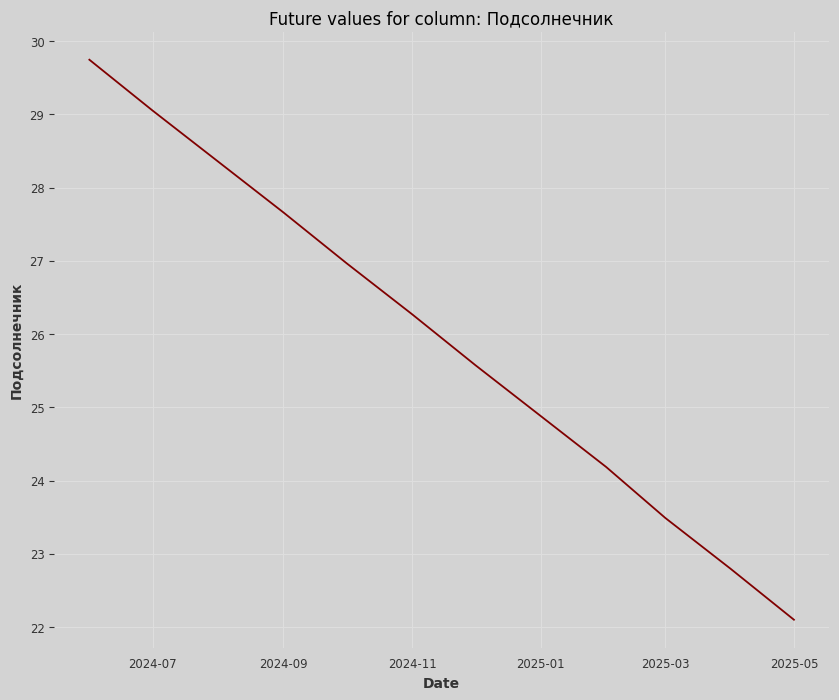

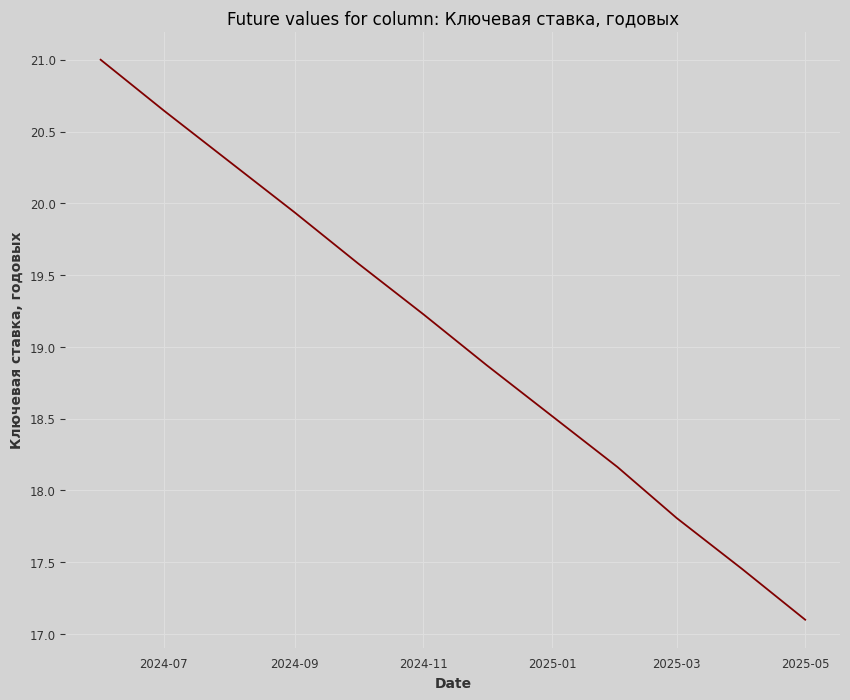

In [28]:
for ts_name, ts_val in zip(FUTURE_FORECASTER_TS_NAME, FUTURE_FORECASTER_TS_VALUES):
    plot_known_feature_value(ts_val,
                             ts_name,
                             pd.date_range(start=FUTURE_DATE + pd.DateOffset(months=1),
                               periods=PREDICTION_HORIZON,
                               freq="MS"))

---
## Forecasting clusers

### predictions

In [30]:
import numpy as np


PREDICTION_HORIZON = 12
PREDICTOR_LAG = 12

IS_BACKTEST: bool = True

SINGLE_DATAPOINT_TO_PRED = "2026-05-14"


TARGET_COL_SUFFIX = "_norm_sum"
MODEL_NAME_FOR_FORECASTER: Literal["tftmodel", "regression", "nbeats", "naiveseasonal", "naivedrift", "naivemean", "naivemovingaverage"] = "tftmodel"
USE_FUTURE_COV = MODEL_NAME_FOR_FORECASTER in ("tftmodel", "regression")
TS_TO_PREDICT = "Соя"

FUTURE_DATE = df_combined.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON)
BACKTEST_DATE = df_combined.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON*2)

train_end = BACKTEST_DATE
past_idx = pd.date_range(start=train_end + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON,
                           freq="MS")
future_idx = pd.date_range(start=past_idx[-1] + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON,
                           freq="MS")

dates = get_month_beginnings(SINGLE_DATAPOINT_TO_PRED)
date_to_pred = dates[1] if len(dates) > 1 else dates[0]
predict_end = pd.to_datetime(date_to_pred)
last_date = df_combined.reset_index()["Date"].iloc[-1]

TOTAL_RANGE = (predict_end.year - last_date.year)*12 + (predict_end.month - last_date.month)

start_date = pd.to_datetime(SINGLE_DATAPOINT_TO_PRED) - relativedelta(months=TOTAL_RANGE)
end_date = pd.to_datetime(SINGLE_DATAPOINT_TO_PRED)

# # Generate the list of monthly dates
# DATE_LIST = pd.date_range(start=start_date, end=end_date, freq='MS').tolist()  # MS = Month Start

# DATE_LIST[-1] = pd.to_datetime(SINGLE_DATAPOINT_TO_PRED)

MODEL_SAVE_PATH = "{model_name}_dataset/{model_name}_for_{category_name}"

FUTURE_FORECASTER_TS_NAME = ["Подсолнечник", "Ключевая ставка, годовых", "Инфляция, г/г"]
FUTURE_FORECASTER_TS_VALUES_RAW = [22.1, 17.1, 12.4]
FUTURE_FORECASTER_TS_VALUES = []
for idx in range(len(FUTURE_FORECASTER_TS_NAME)):
    pred_ts_name = FUTURE_FORECASTER_TS_NAME[idx]
    df_to_get = df_combined if pred_ts_name in df_combined.columns else macro_data
    FUTURE_FORECASTER_TS_VALUES.append(
        np.linspace(df_to_get[pred_ts_name][-1],
                    FUTURE_FORECASTER_TS_VALUES_RAW[idx],
                    TOTAL_RANGE)
    )

PERSIST_MODEL = True
REFIT_MODEL = True


In [31]:
# Assuming df_combined is your main DataFrame with datetime index
# First, extend the index to the prediction date
new_dates = pd.date_range(start=df_combined.index[-1] + pd.DateOffset(months=1),
                          end=SINGLE_DATAPOINT_TO_PRED,
                          freq='MS')
PREDICTION_HORIZON = len(new_dates)
# Create a new DataFrame with the extended dates
df_extended = pd.DataFrame(index=new_dates, columns=df_combined.columns)
macro_extended = pd.DataFrame(index=new_dates, columns=macro_data.columns)

# Combine the original and extended DataFrames
df_updated = pd.concat([df_combined, df_extended])
macro_updated = pd.concat([macro_data, macro_extended])
FUTURE_FORECASTER_TS_VALUES = []
# Now update the FUTURE_FORECASTER_TS_NAME columns with the new values
for idx, col_name in enumerate(FUTURE_FORECASTER_TS_NAME):
    if col_name in df_updated.columns:
        # Get the future values for this column
        future_value = FUTURE_FORECASTER_TS_VALUES_RAW[idx]
        future_values = np.linspace(df_combined[col_name][-1],
                        future_value,
                        PREDICTION_HORIZON)
        FUTURE_FORECASTER_TS_VALUES.append(future_values)
        # Update the values for the extended period
        # Make sure the length matches
        if len(future_values) == PREDICTION_HORIZON:
            df_updated.loc[new_dates, col_name] = future_values

    elif col_name in macro_updated.columns:
        # Get the future values for this column
        future_value = FUTURE_FORECASTER_TS_VALUES_RAW[idx]
        future_values = np.linspace(macro_data[col_name][-1],
                        future_value,
                        PREDICTION_HORIZON)
        FUTURE_FORECASTER_TS_VALUES.append(future_values)
        if len(future_values) == PREDICTION_HORIZON:
            macro_updated.loc[new_dates, col_name] = future_values

BACKTEST_DATE = df_combined.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON*2)

train_end = BACKTEST_DATE
past_idx = pd.date_range(start=train_end + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON,
                           freq="MS")
future_idx = pd.date_range(start=past_idx[-1] + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON,
                           freq="MS")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 5.1 K  | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 528    | train
6  | static_context_grn                | _GatedResidualNetwork            | 1.1 K  | train
7  | static_cont

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


Predicting: |                                                                                    | 0/? [00:00<…

...

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


Predicting: |                                                                                    | 0/? [00:00<…

Saved forecaster to tftmodel_dataset/tftmodel_for_Ключевая ставка, годовых.pkl and model to tftmodel_dataset/tftmodel_for_Ключевая ставка, годовых_model.pth


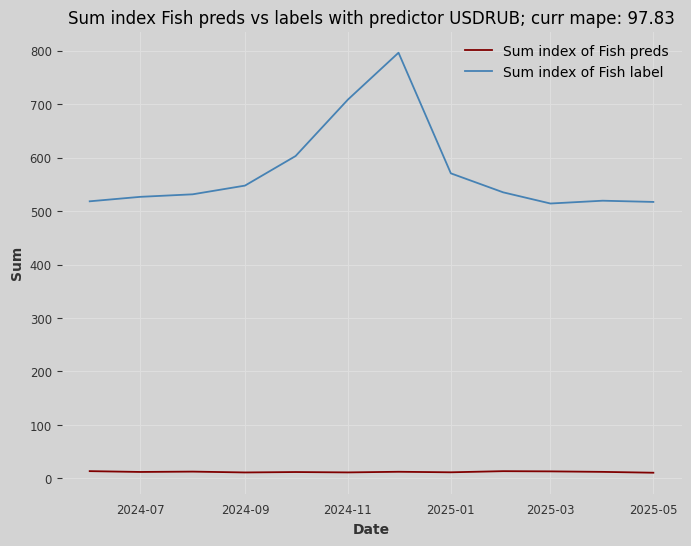

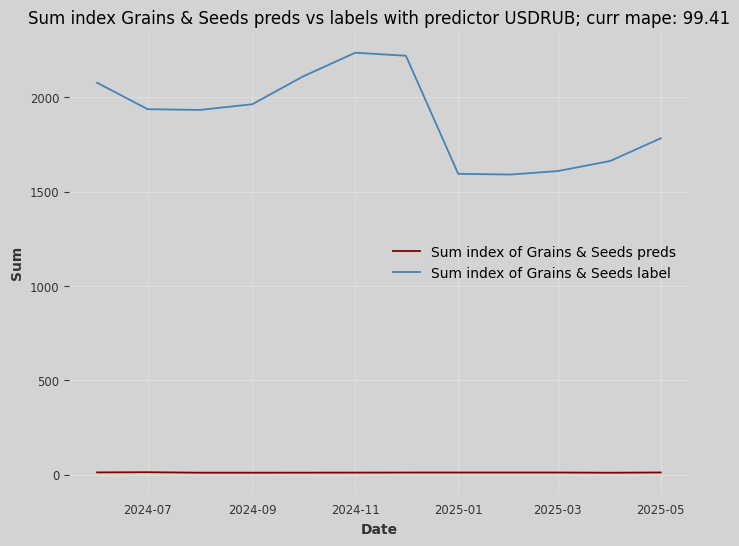

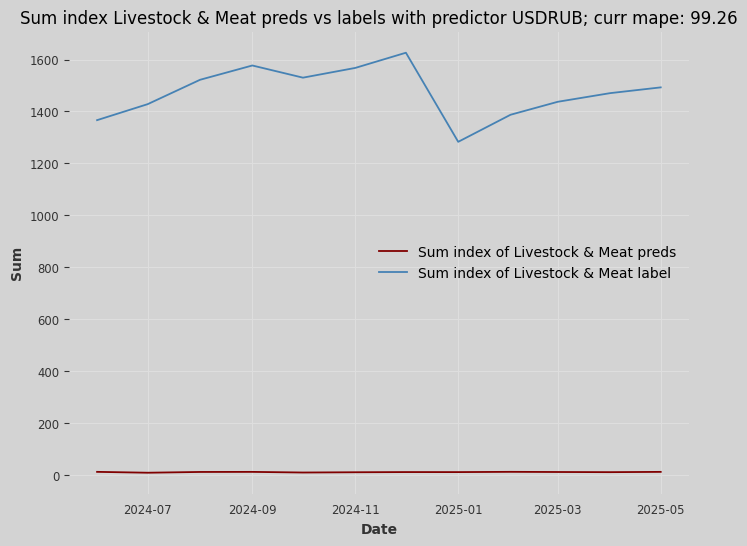

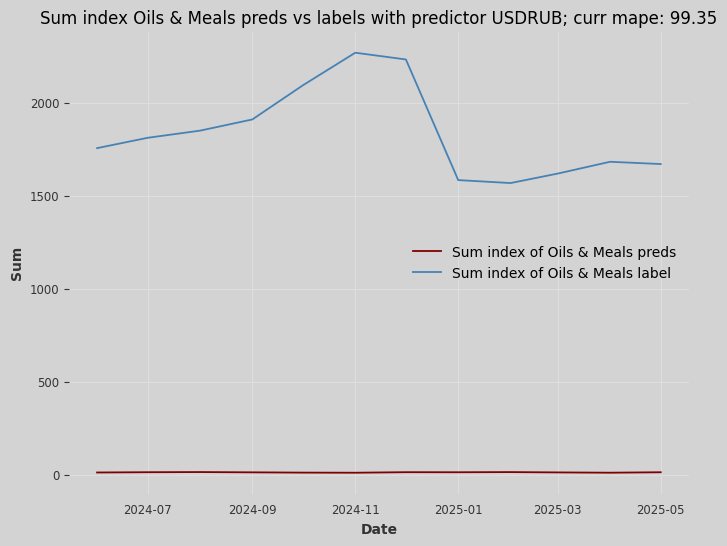

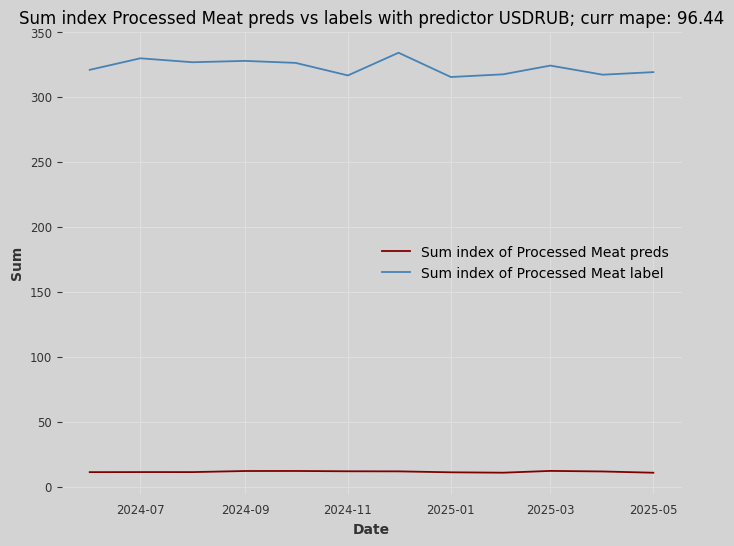

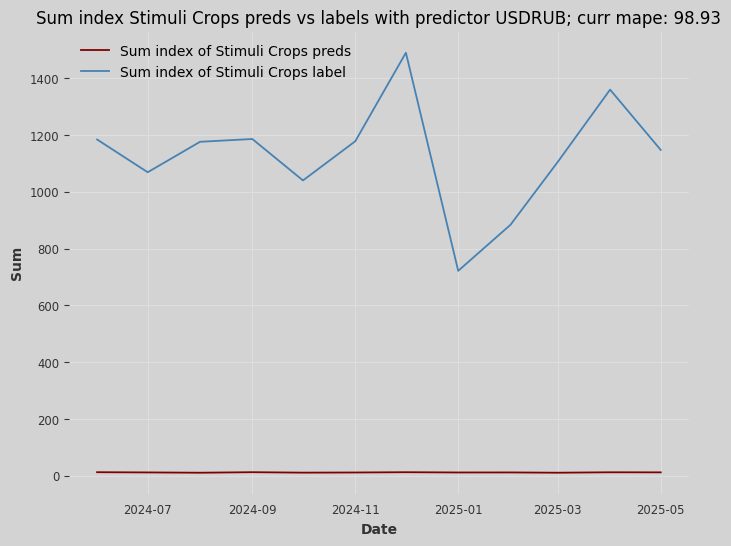

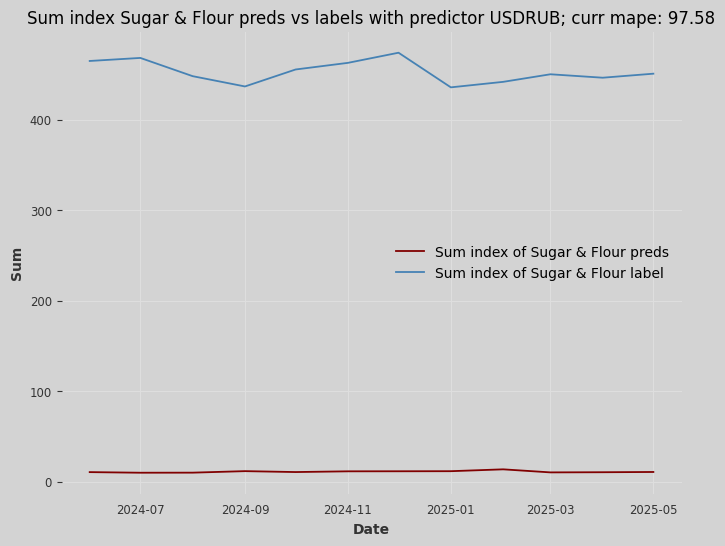

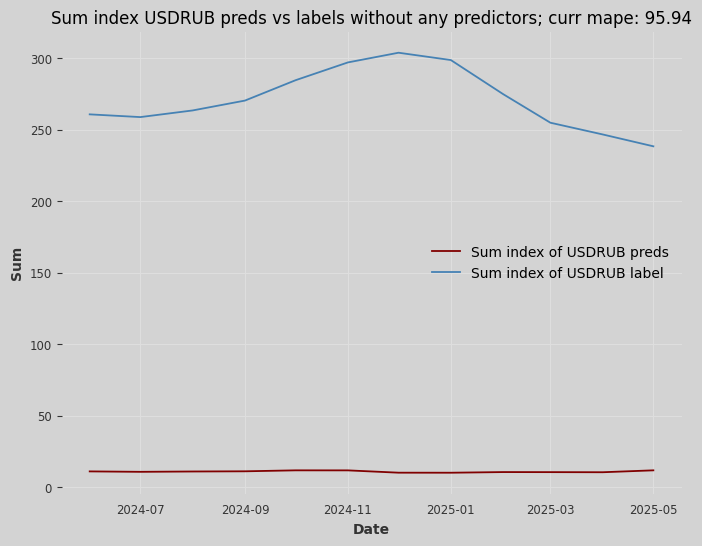

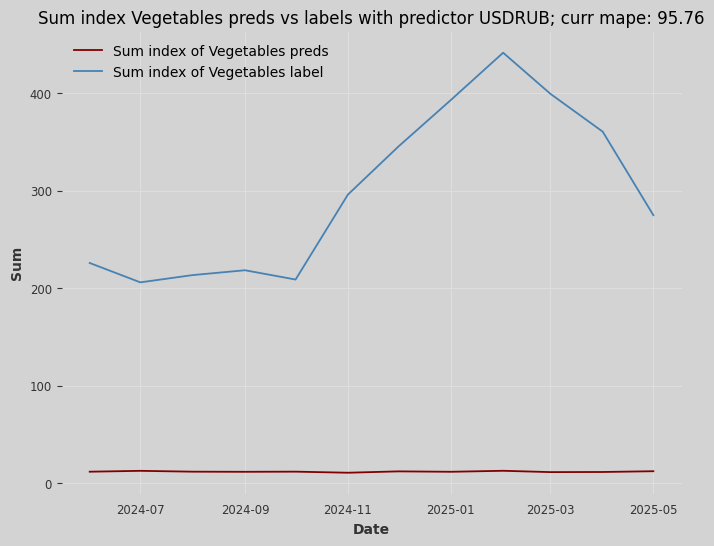

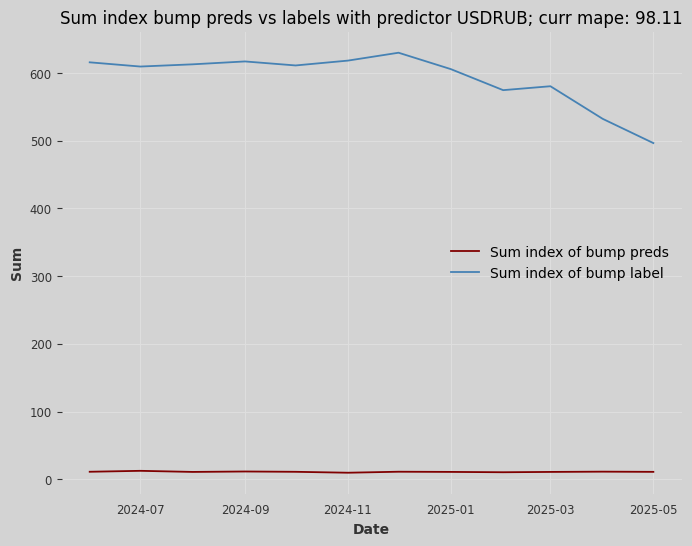

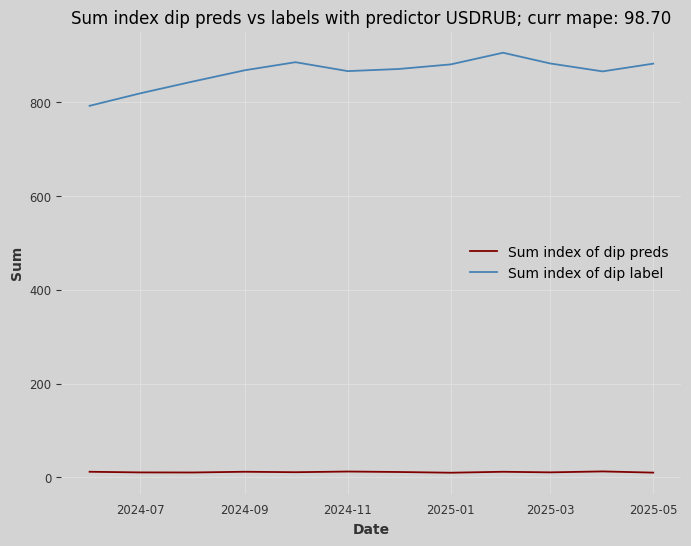

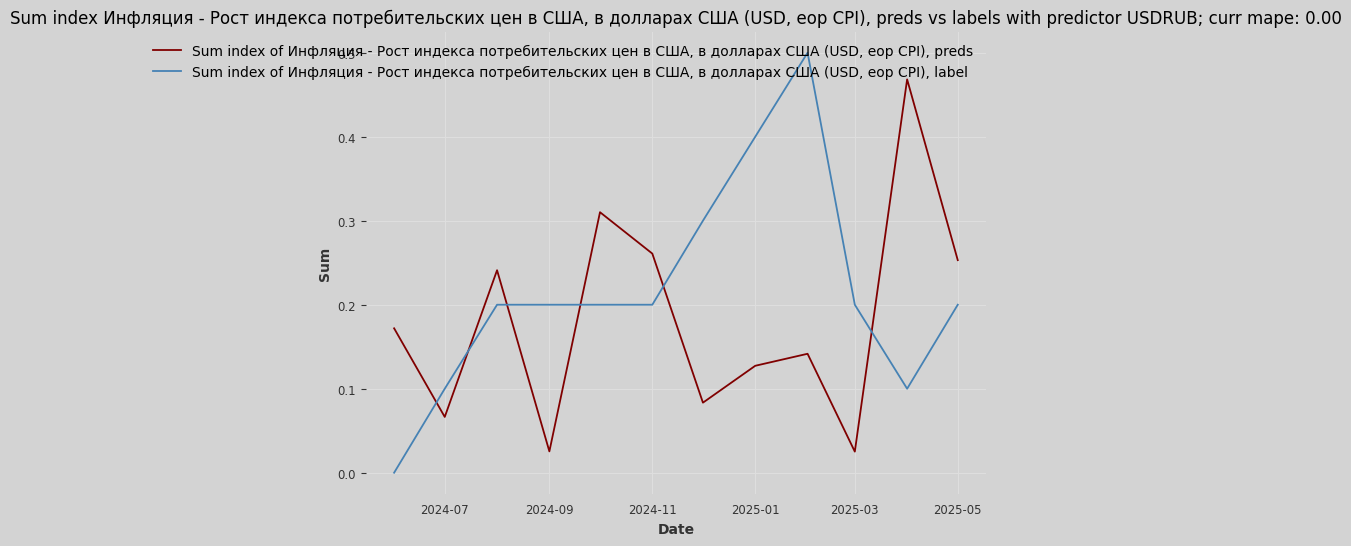

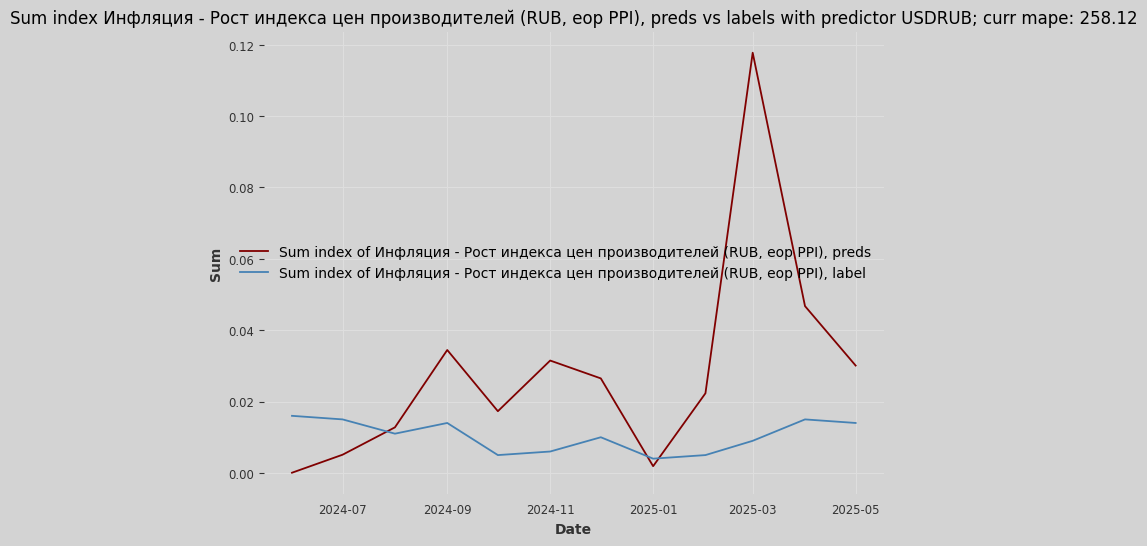

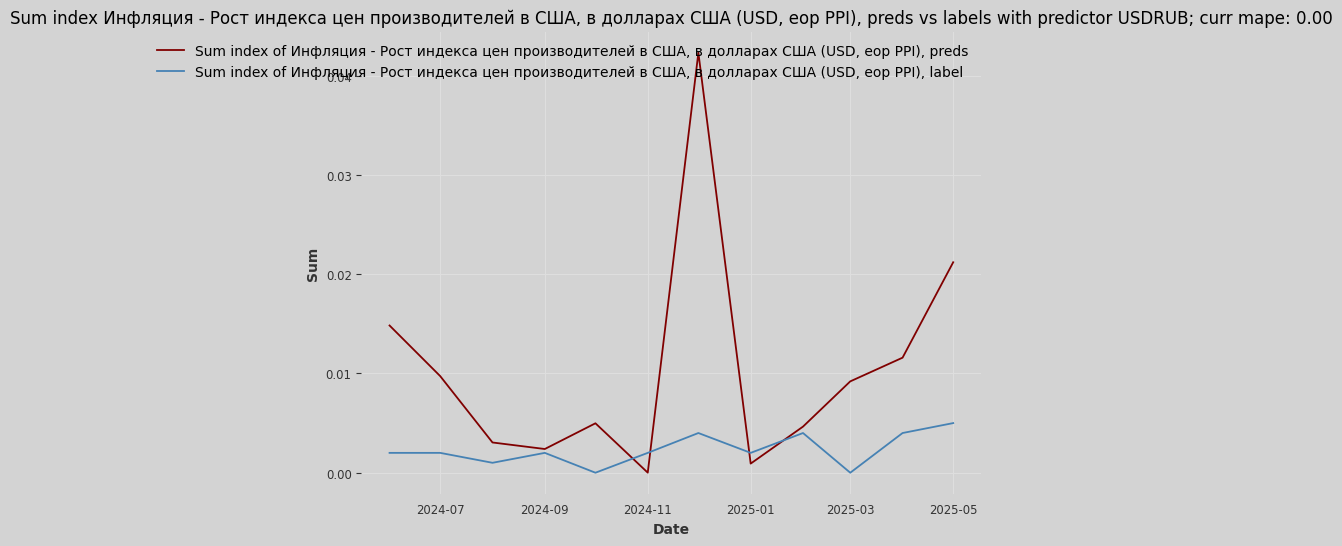

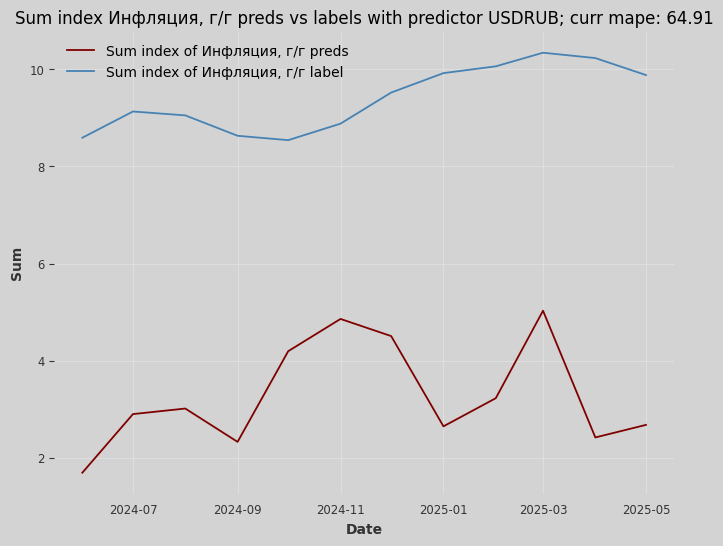

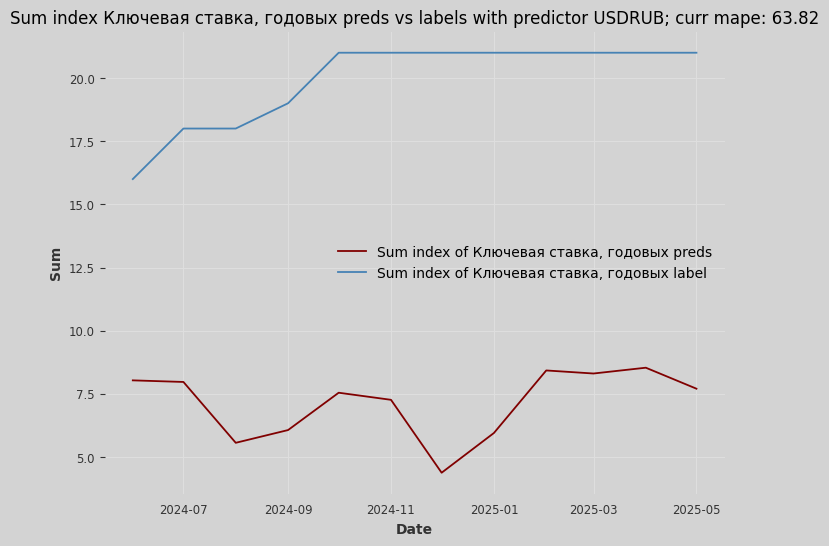

In [32]:
models = train_model_and_eval_res(df_updated,
                         macro_updated,
                         past_idx = past_idx,
                         future_idx = future_idx,
                         predict_up_to=SINGLE_DATAPOINT_TO_PRED,
                         category_map = CATEGORY_MAP,
                         best_predictors_for_idx = BEST_PREDICTORS_FOR_INDEX,
                         target_col_suffix = TARGET_COL_SUFFIX,
                         future_forecaster_ts_name = FUTURE_FORECASTER_TS_NAME,
                         future_forecaster_ts_values = FUTURE_FORECASTER_TS_VALUES,
                         model_name = MODEL_NAME_FOR_FORECASTER,
                         use_future_macro = USE_FUTURE_COV,
                         prediction_horizon = PREDICTION_HORIZON,
                         dir_to_save_plots = f"darts_result_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         dir_to_save_tables = f"darts_result_tables_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         refit=REFIT_MODEL,
                         is_backtest=IS_BACKTEST
)
# TODO: Научинтся конвертить в TimeSeries

---
## Inference model

In [33]:
TARGET_COL_SUFFIX = "_norm_sum"

In [34]:
models = load_models(MODEL_NAME_FOR_FORECASTER)

[OK] Loaded forecaster ← tftmodel_dataset/tftmodel_for_Stimuli Crops.pkl
[OK] Loaded model      ← tftmodel_dataset/tftmodel_for_Stimuli Crops_model.pth
[OK] Loaded forecaster ← tftmodel_dataset/tftmodel_for_Livestock & Meat.pkl
[OK] Loaded model      ← tftmodel_dataset/tftmodel_for_Livestock & Meat_model.pth
[OK] Loaded forecaster ← tftmodel_dataset/tftmodel_for_Processed Meat.pkl
[OK] Loaded model      ← tftmodel_dataset/tftmodel_for_Processed Meat_model.pth
[OK] Loaded forecaster ← tftmodel_dataset/tftmodel_for_dip.pkl
[OK] Loaded model      ← tftmodel_dataset/tftmodel_for_dip_model.pth
[OK] Loaded forecaster ← tftmodel_dataset/tftmodel_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),.pkl
[OK] Loaded model      ← tftmodel_dataset/tftmodel_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),_model.pth
[OK] Loaded forecaster ← tftmodel_dataset/tftmodel_for_Fish.pkl
[OK] Loaded model      ← tftmodel_dataset/tftmodel_f

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


Predicting: |                                                                                    | 0/? [00:00<…

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


2025-06-01    0.057516
2025-07-01    0.062329
2025-08-01    0.065506
2025-09-01    0.066928
2025-10-01    0.070858
2025-11-01    0.061686
2025-12-01    0.067557
2026-01-01    0.064173
2026-02-01    0.070592
2026-03-01    0.060958
2026-04-01    0.065737
2026-04-14    0.063608
Name: Кукуруза_preds, dtype: float64
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


...

Predicting: |                                                                                    | 0/? [00:00<…

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MACRO PREDICTIONS COLUMNS
Index(['Инфляция, г/г', 'Инфляция, г/г_preds'], dtype='object')
2025-05-01    4.464044
2025-06-01    2.797854
2025-07-01    2.300007
2025-08-01    2.918963
2025-09-01    2.336900
2025-10-01    4.685792
2025-11-01    3.091072
2025-12-01    4.041172
2026-01-01    2.421196
2026-02-01    4.898365
2026-03-01    2.626361
2026-04-01    2.390017
Freq: MS, Name: Инфляция, г/г_preds, dtype: float64
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


Predicting: |                                                                                    | 0/? [00:00<…

2025-06-01    3.544983
2025-07-01    3.559727
2025-08-01    3.975204
2025-09-01    4.150507
2025-10-01    3.658776
2025-11-01    3.584643
2025-12-01    3.570167
2026-01-01    3.617532
2026-02-01    3.857679
2026-03-01    3.961098
2026-04-01    4.485121
2026-04-14    2.955446
Name: USDRUB_preds, dtype: float64


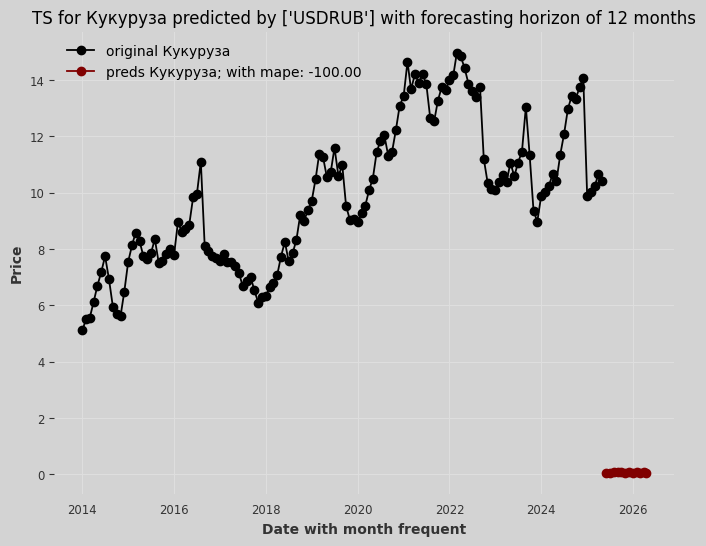

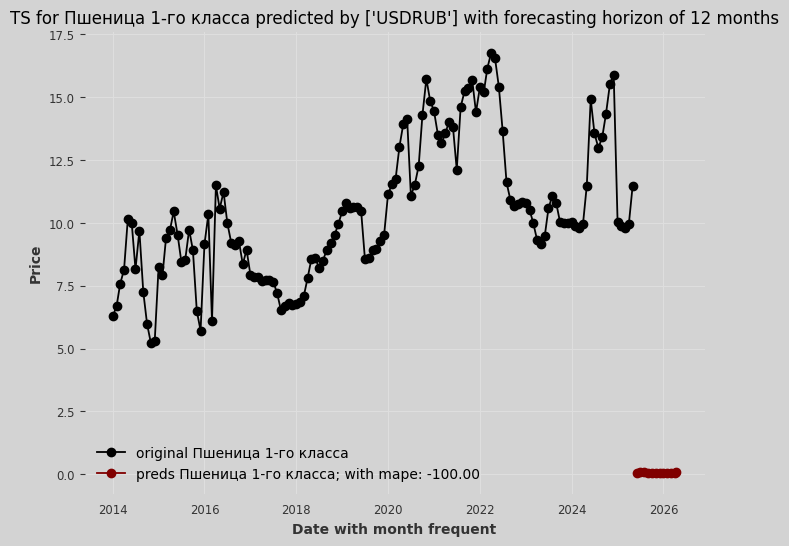

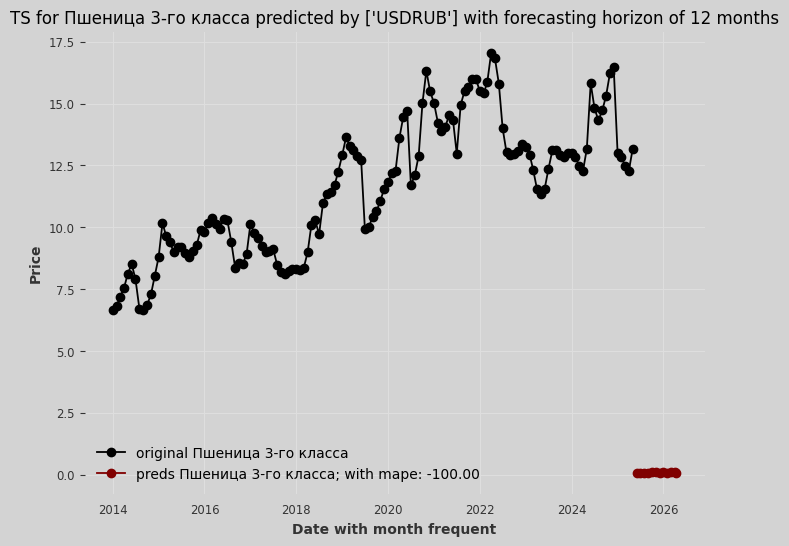

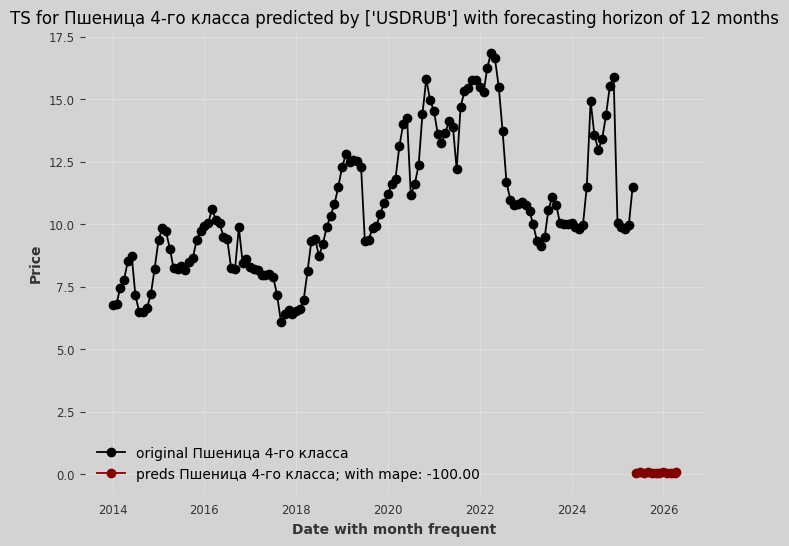

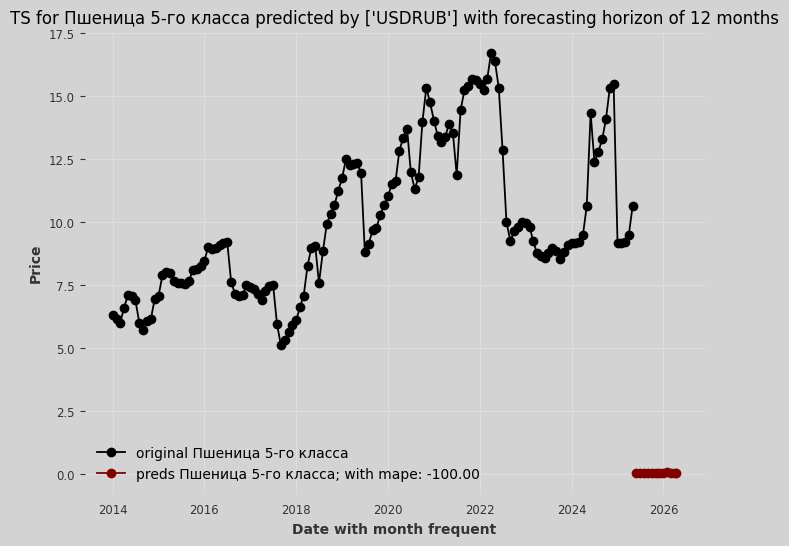

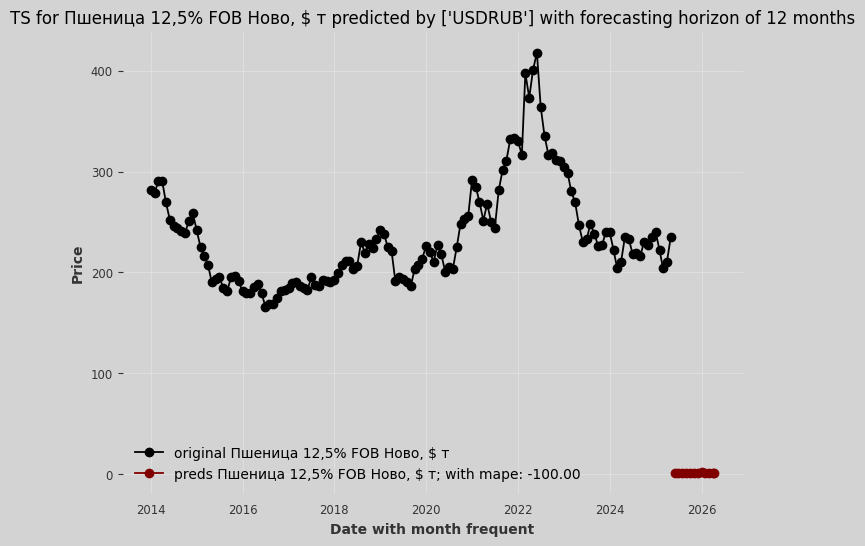

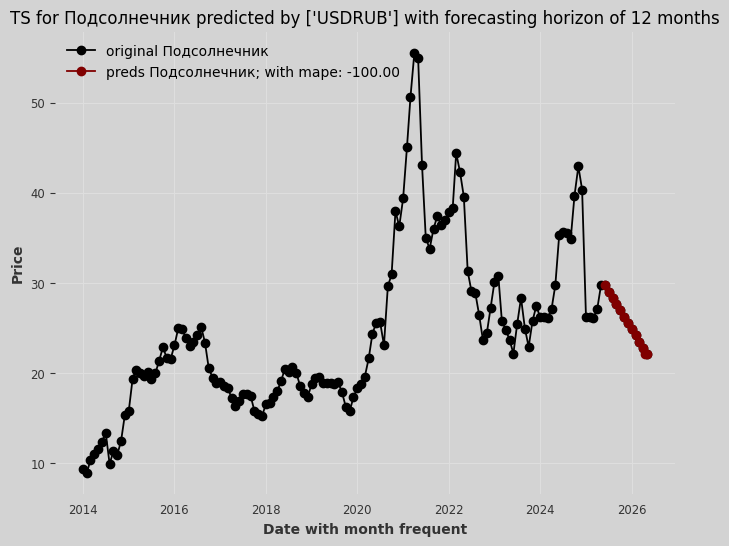

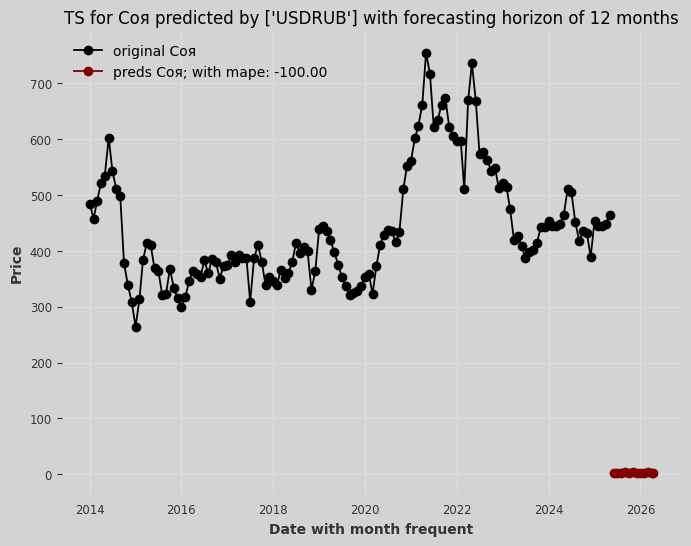

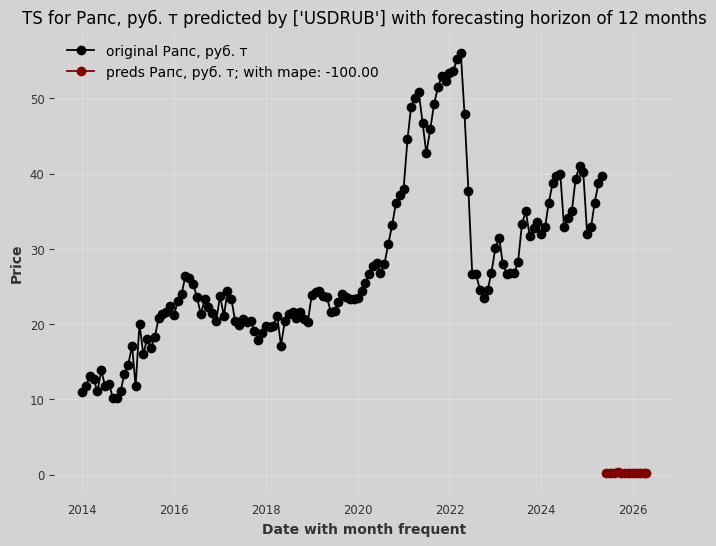

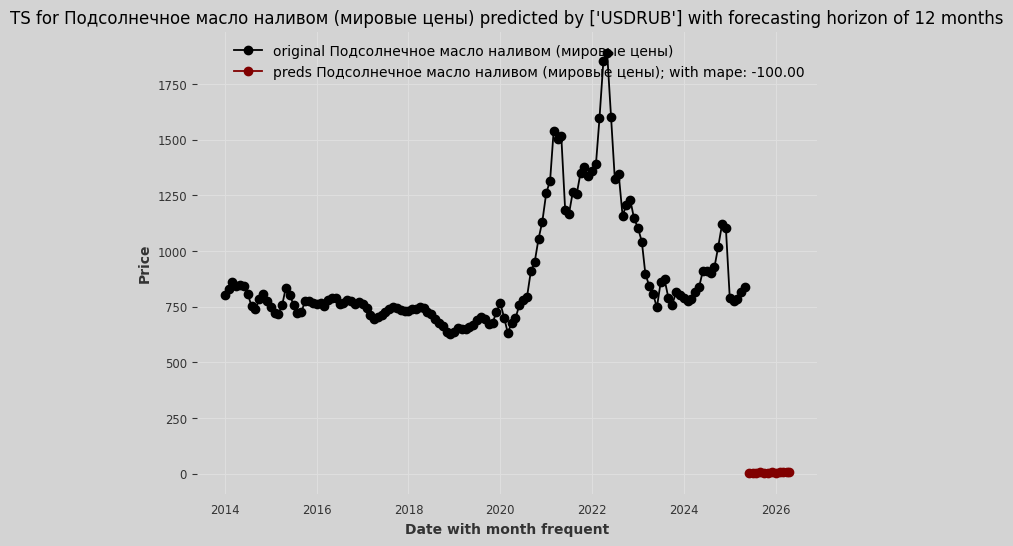

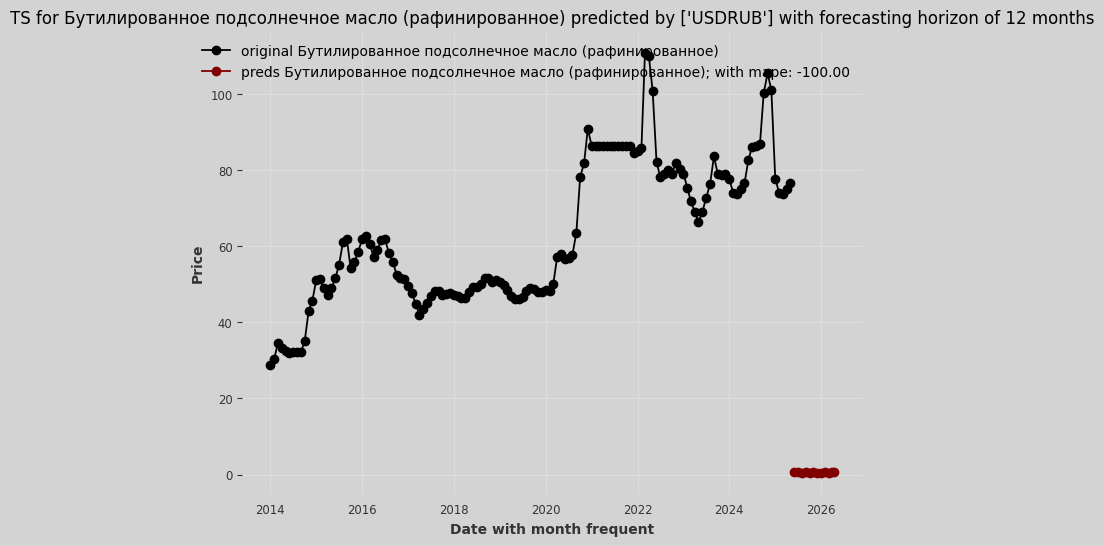

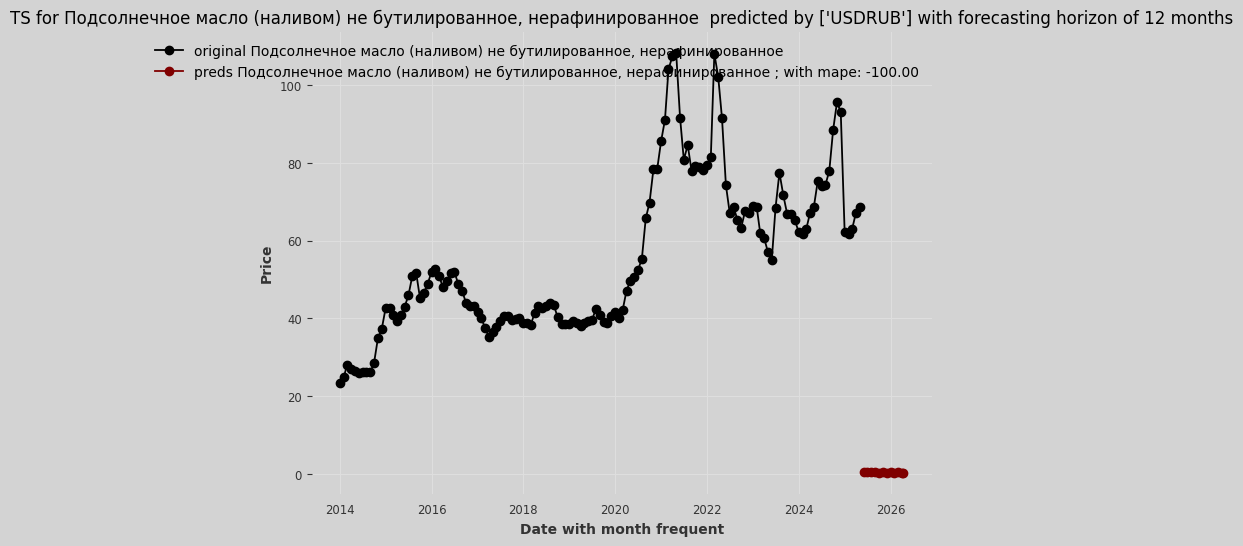

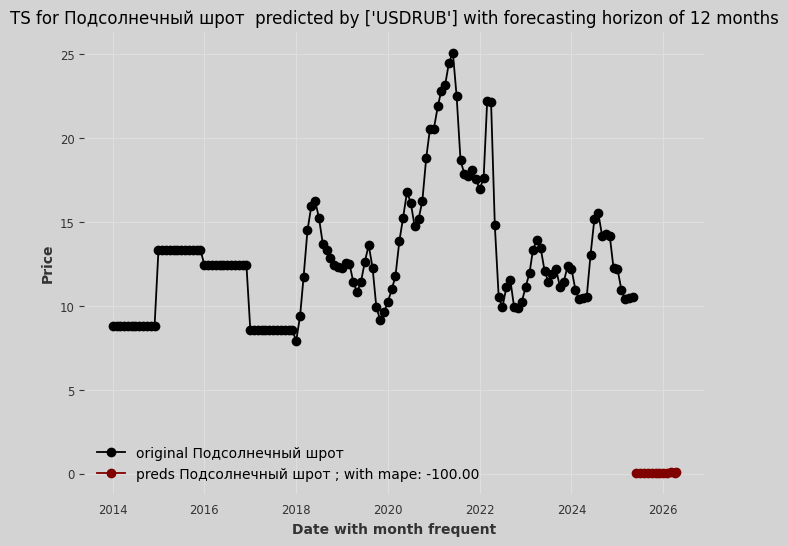

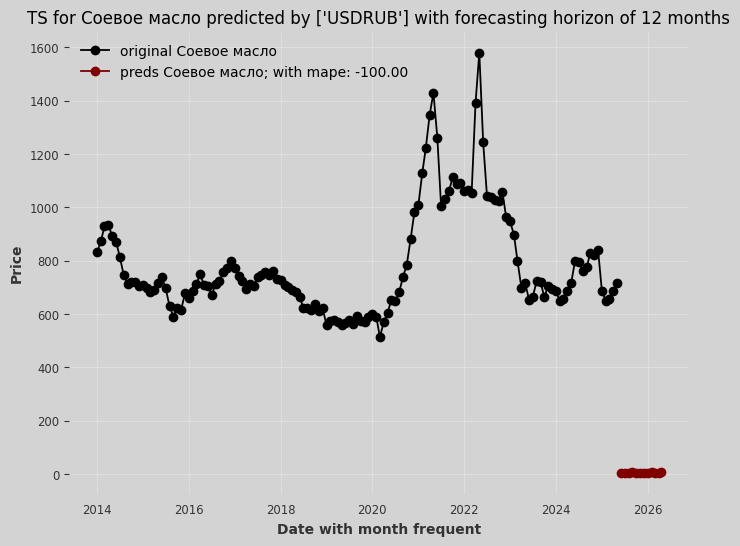

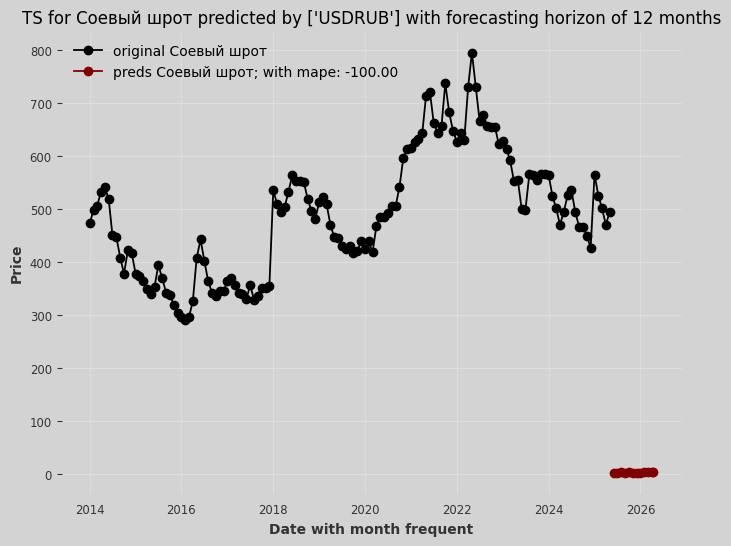

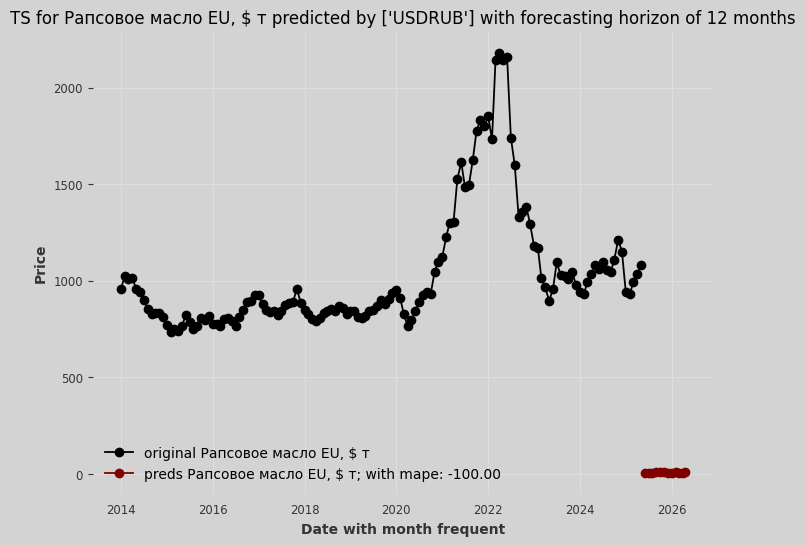

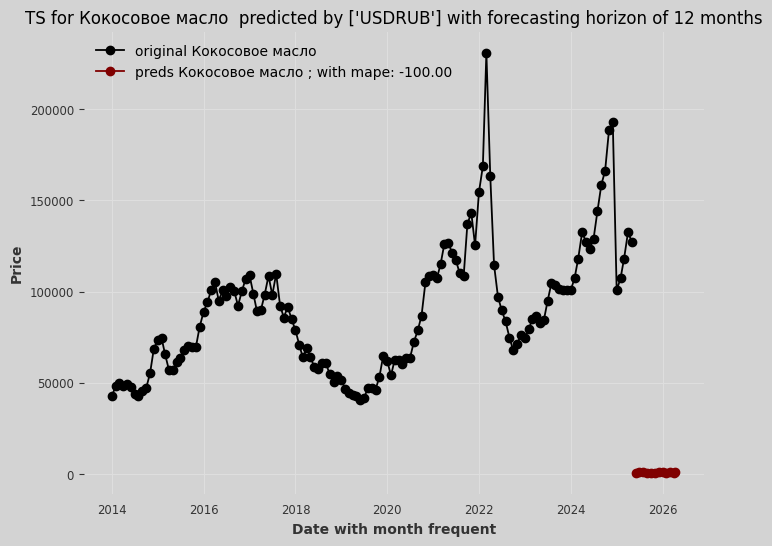

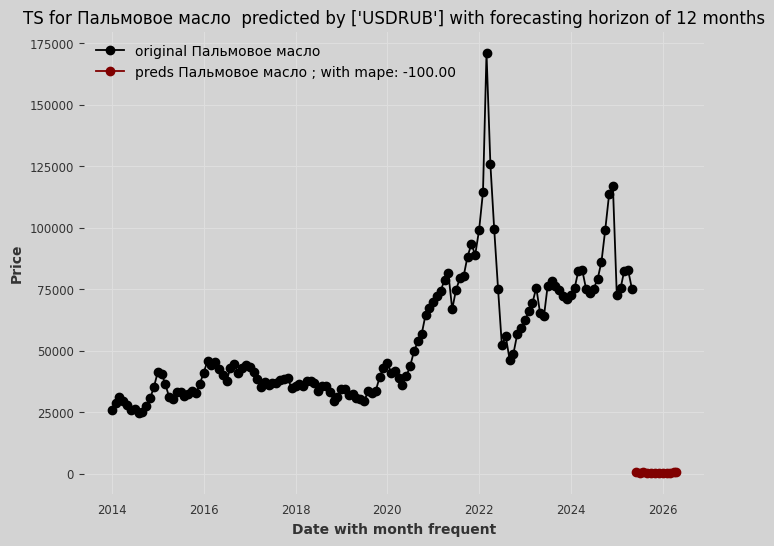

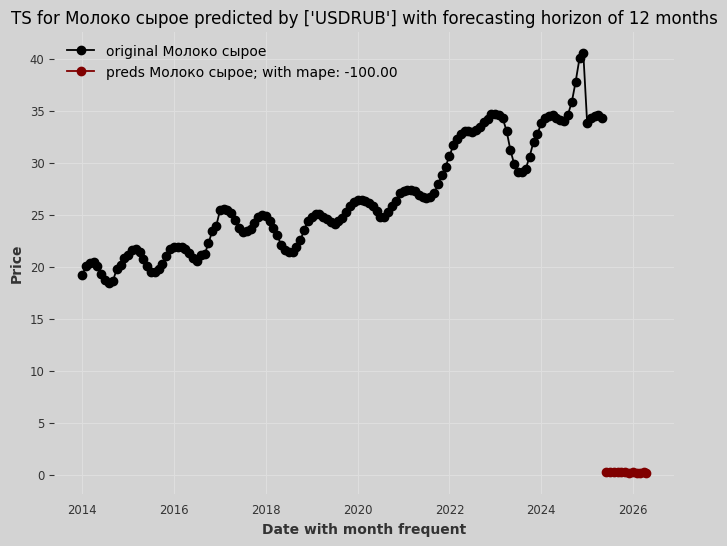

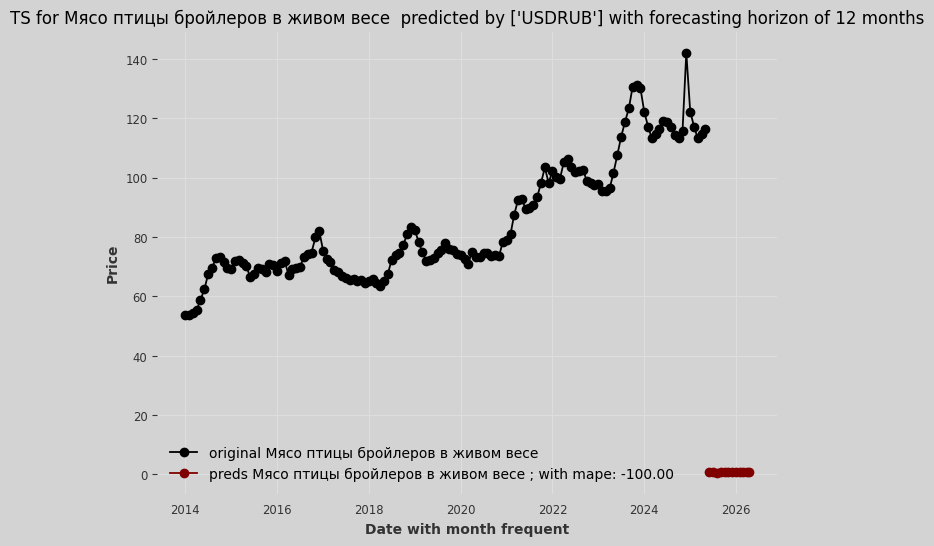

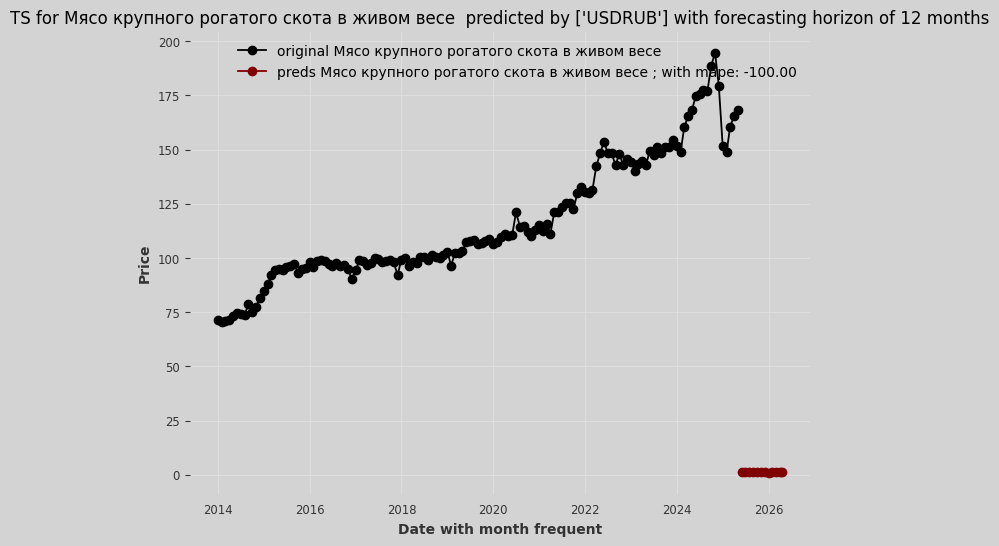

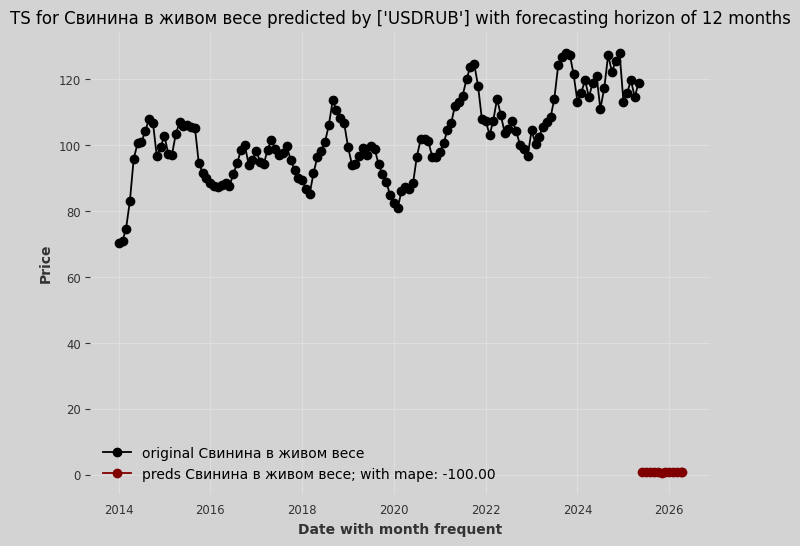

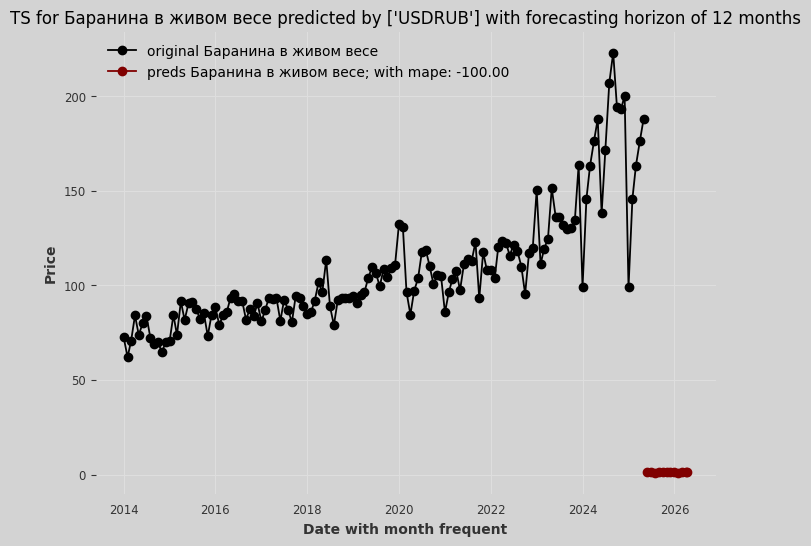

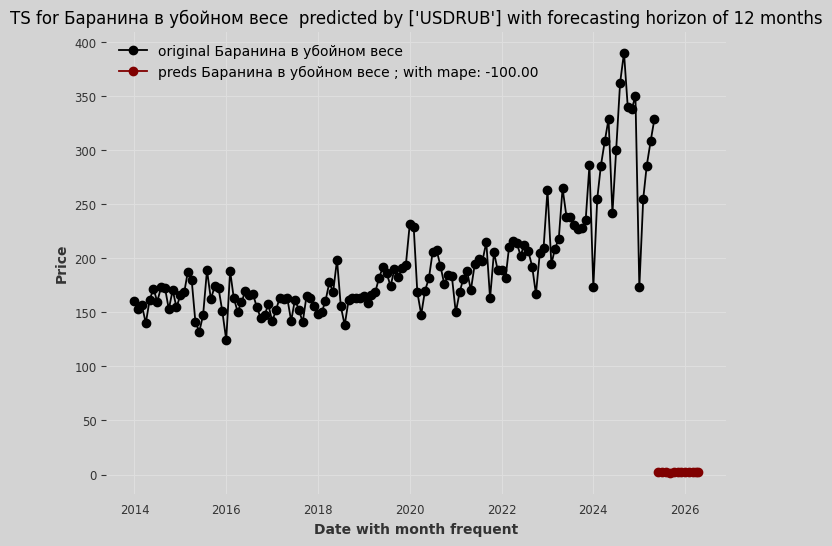

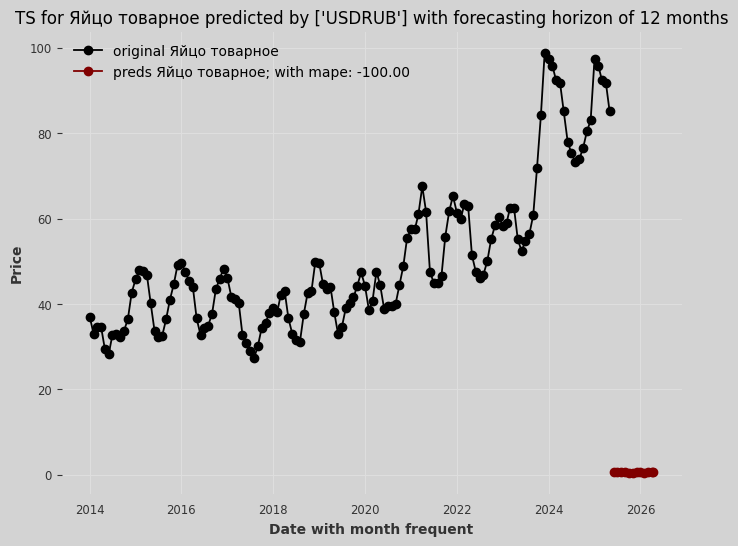

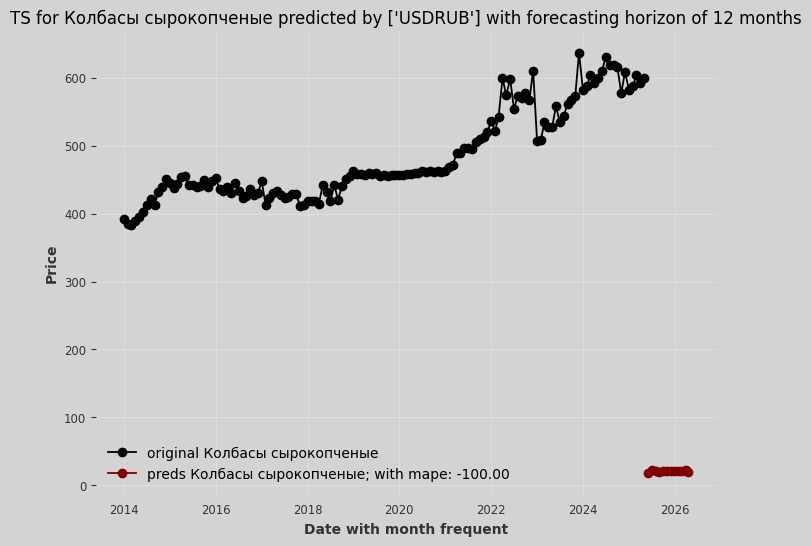

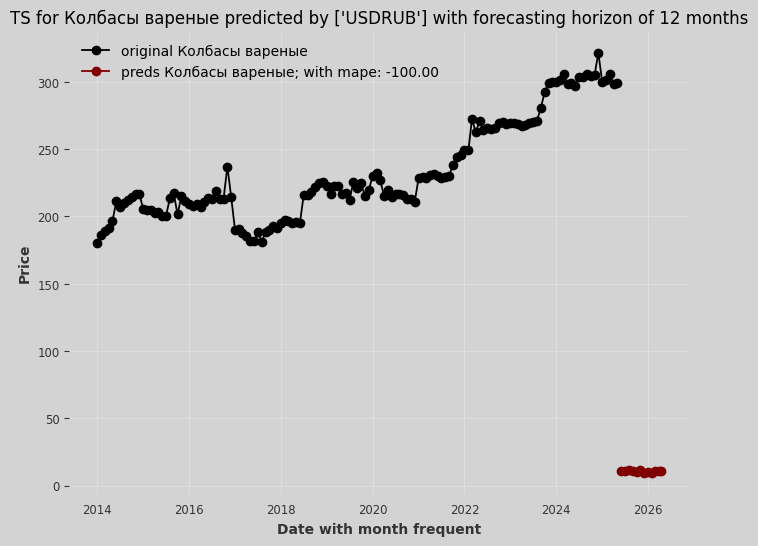

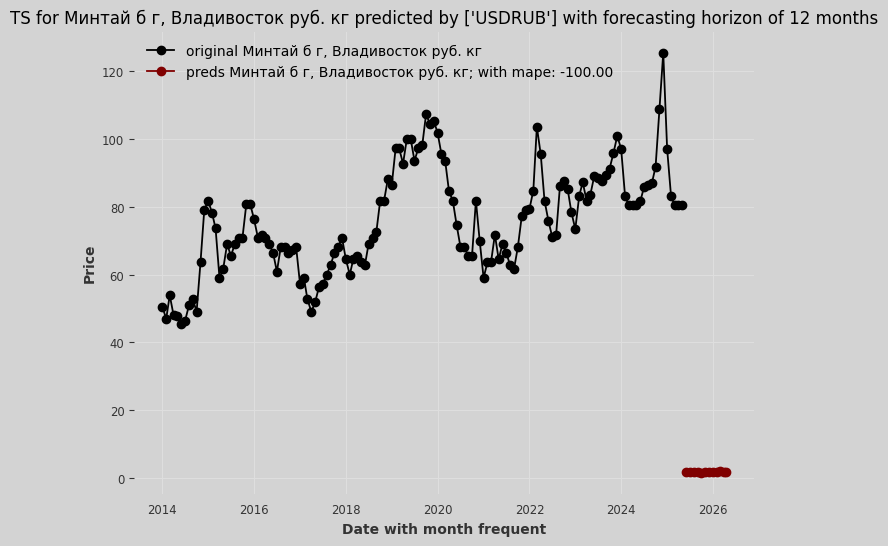

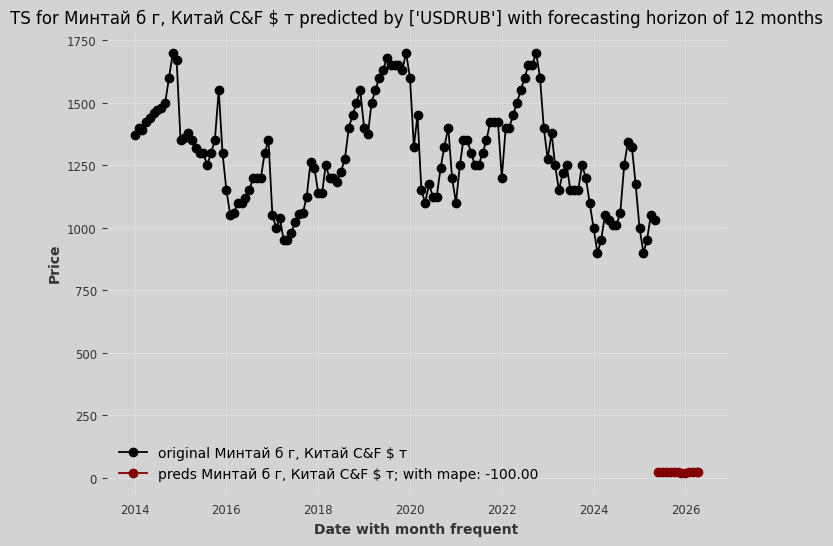

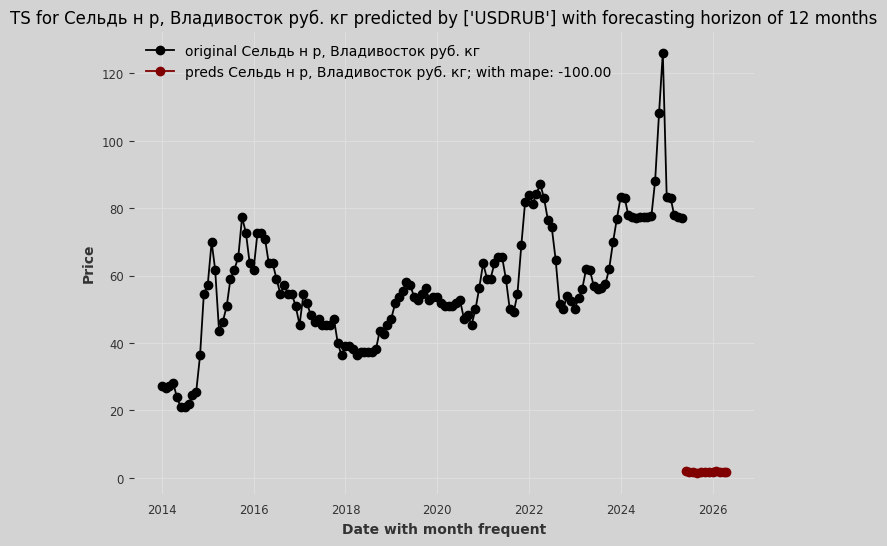

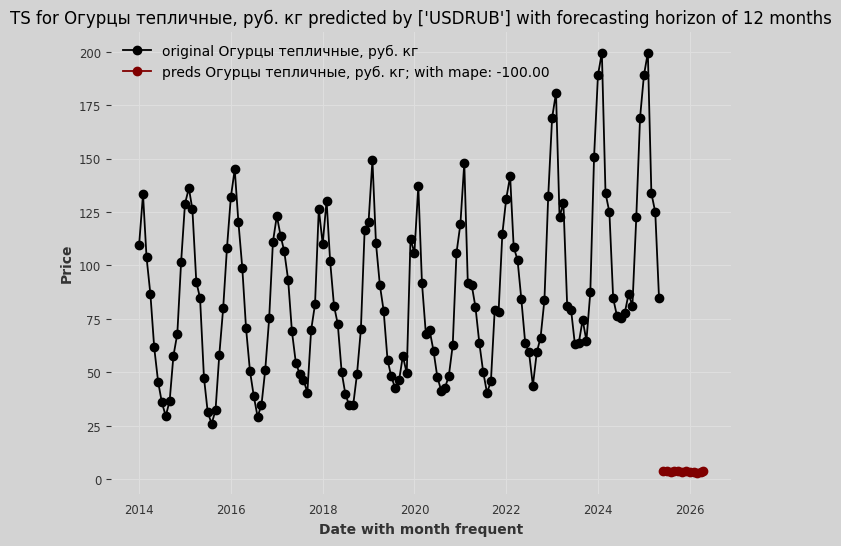

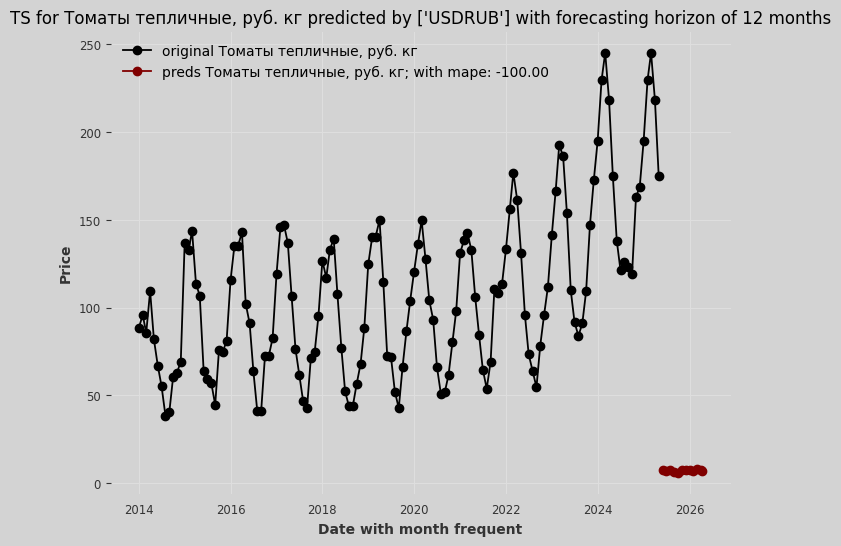

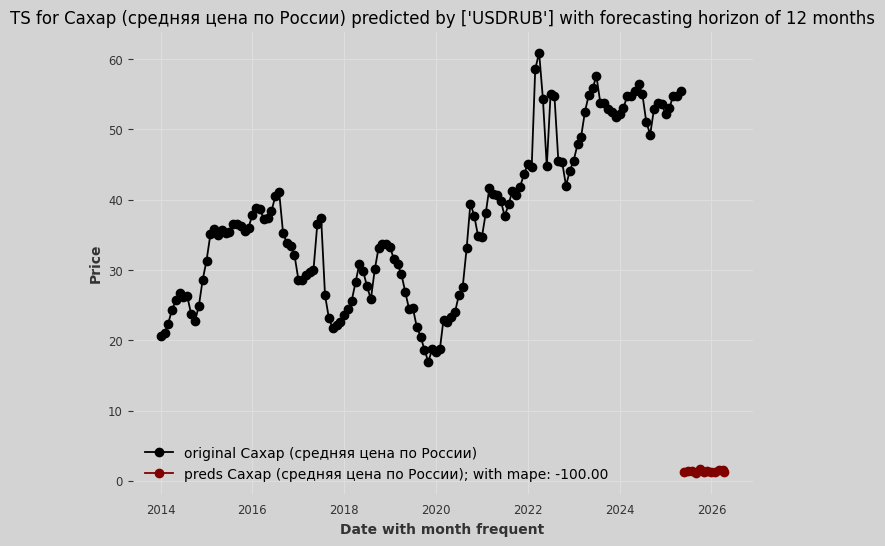

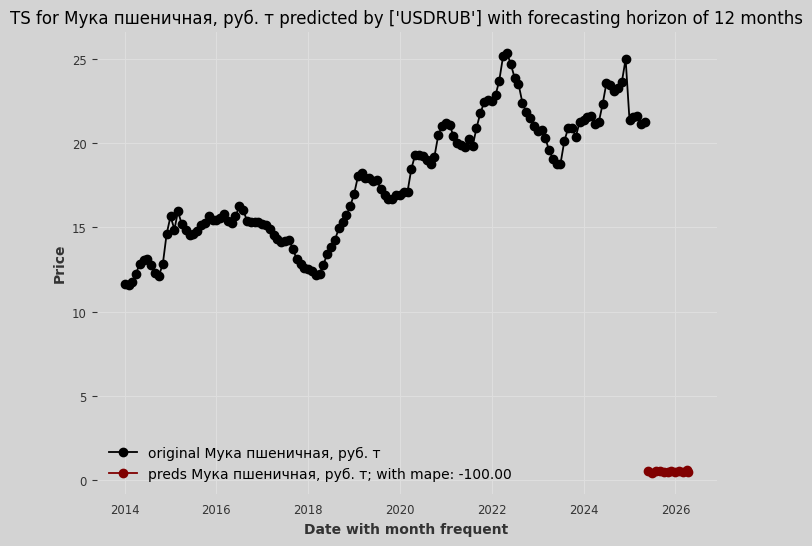

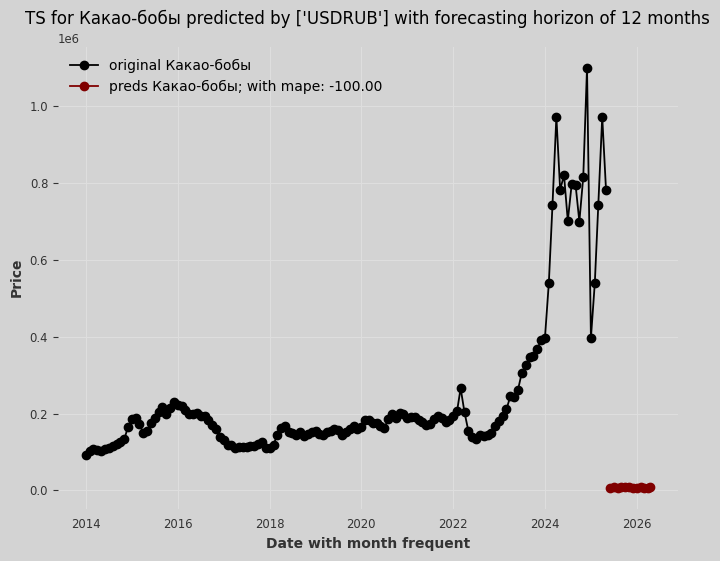

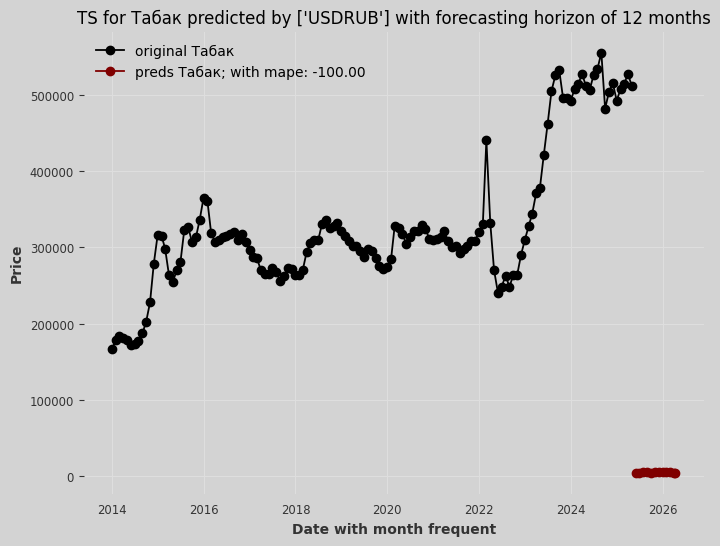

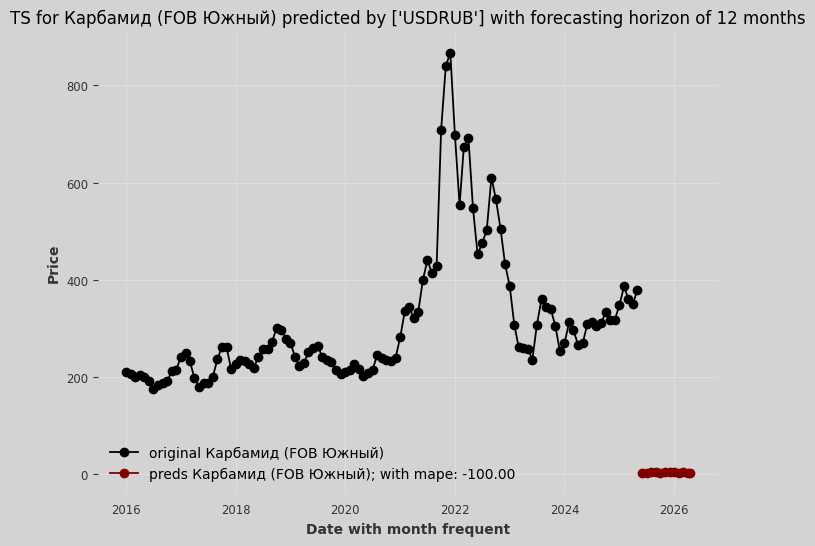

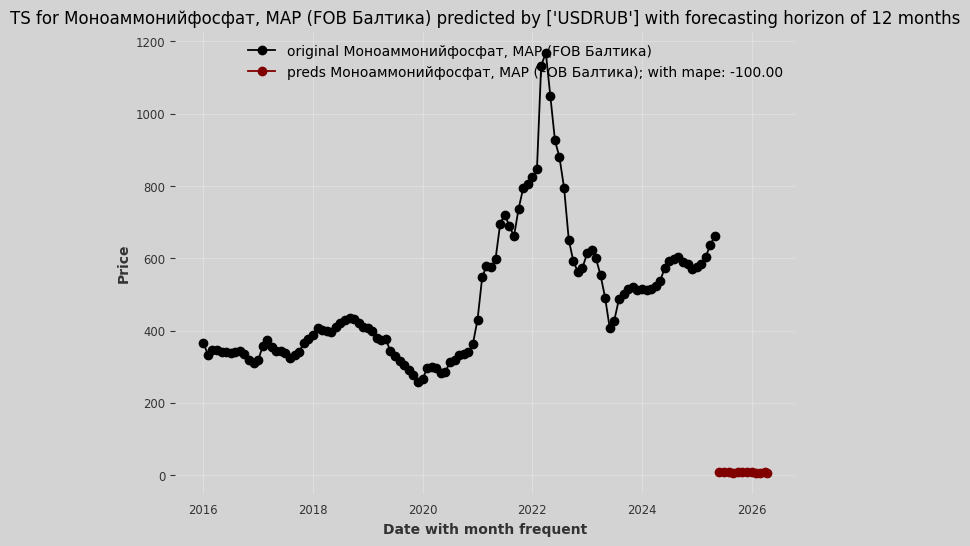

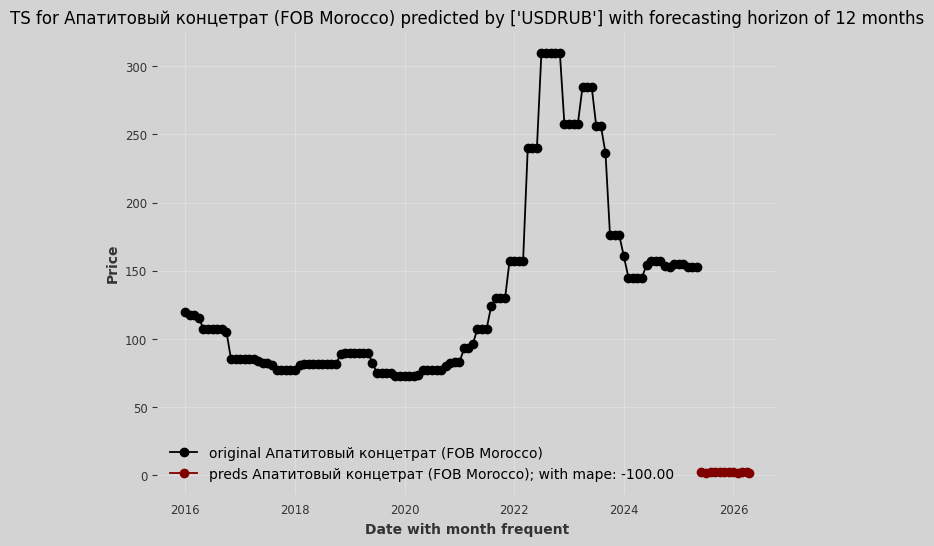

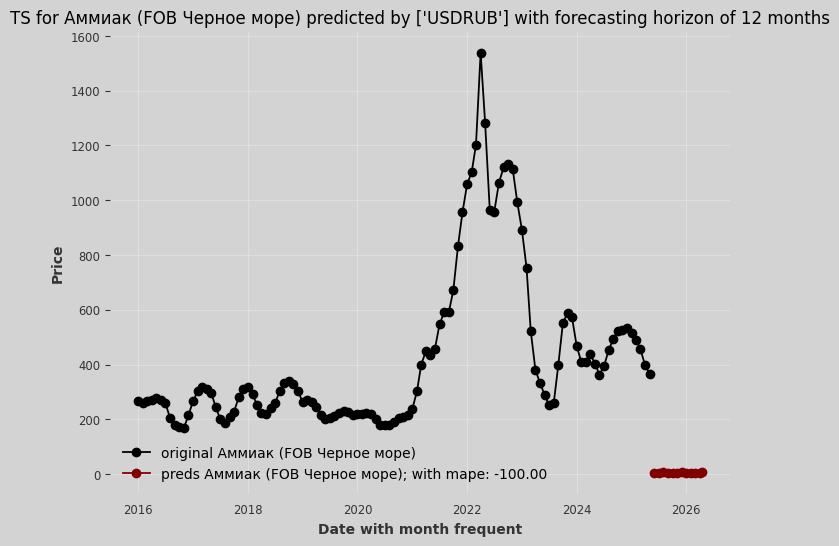

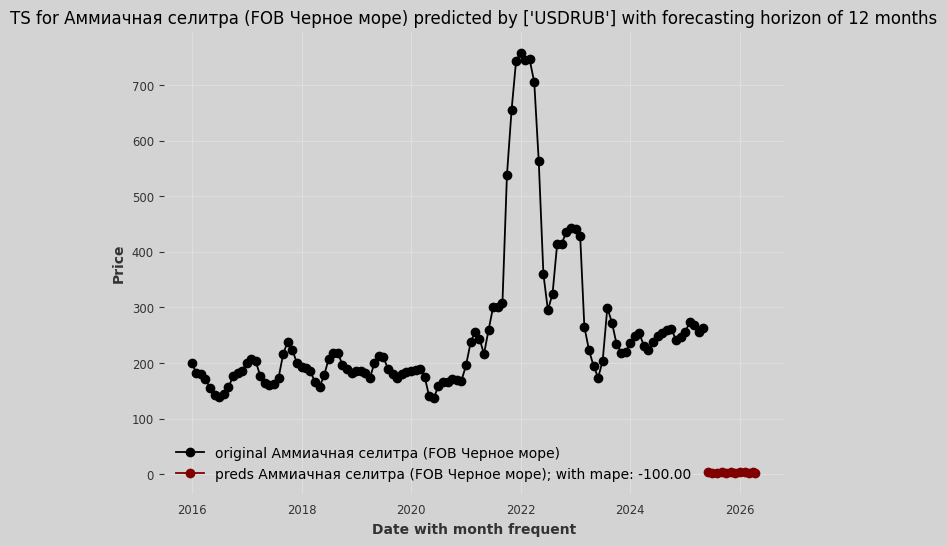

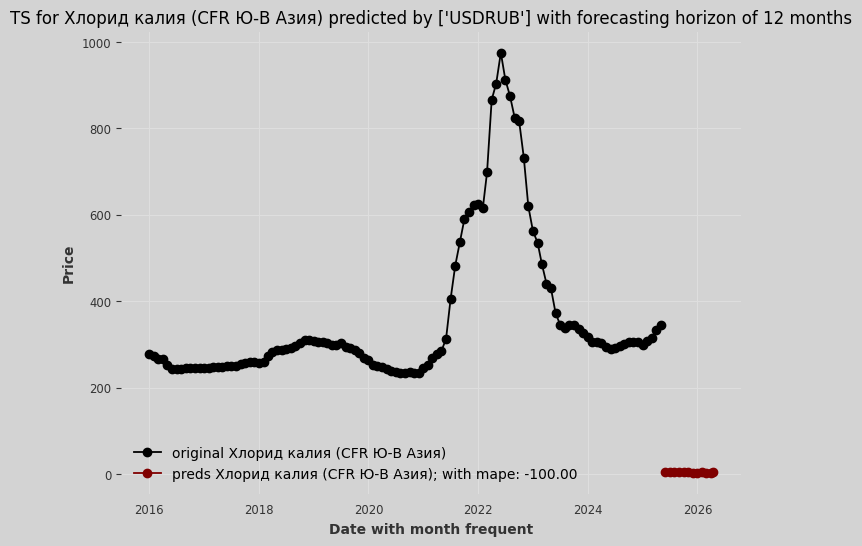

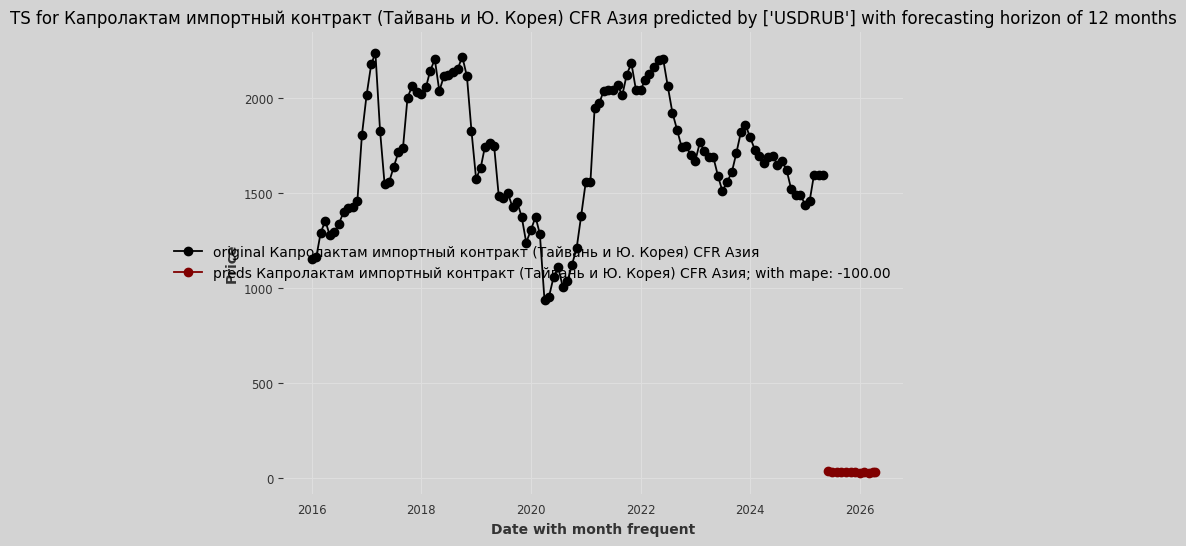

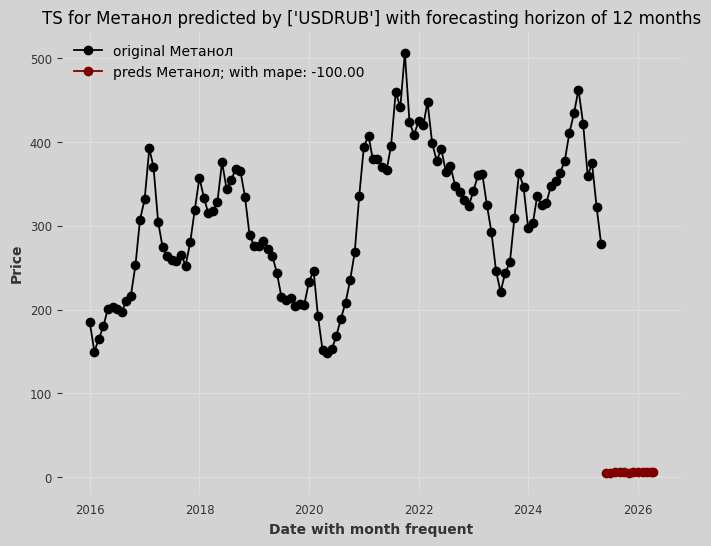

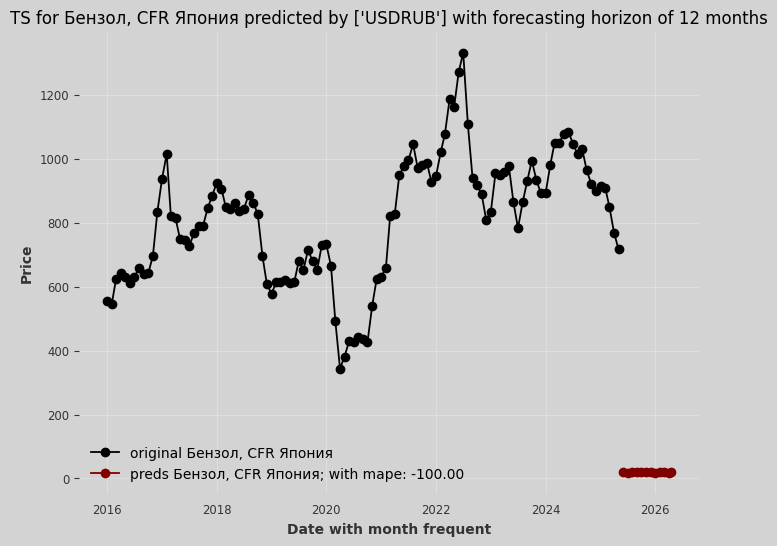

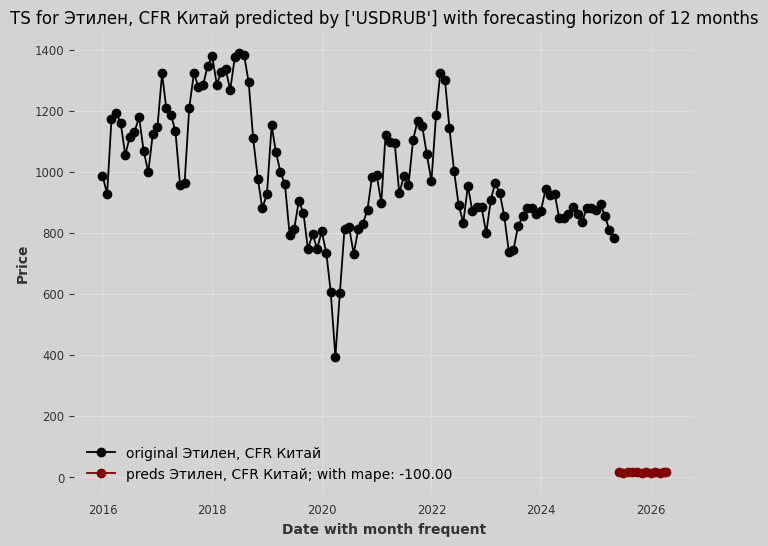

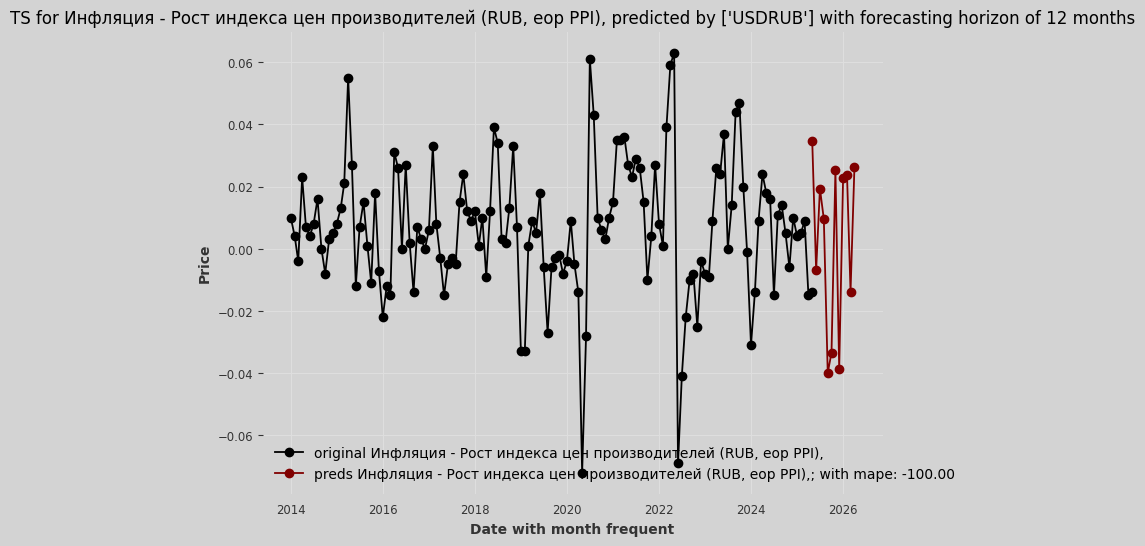

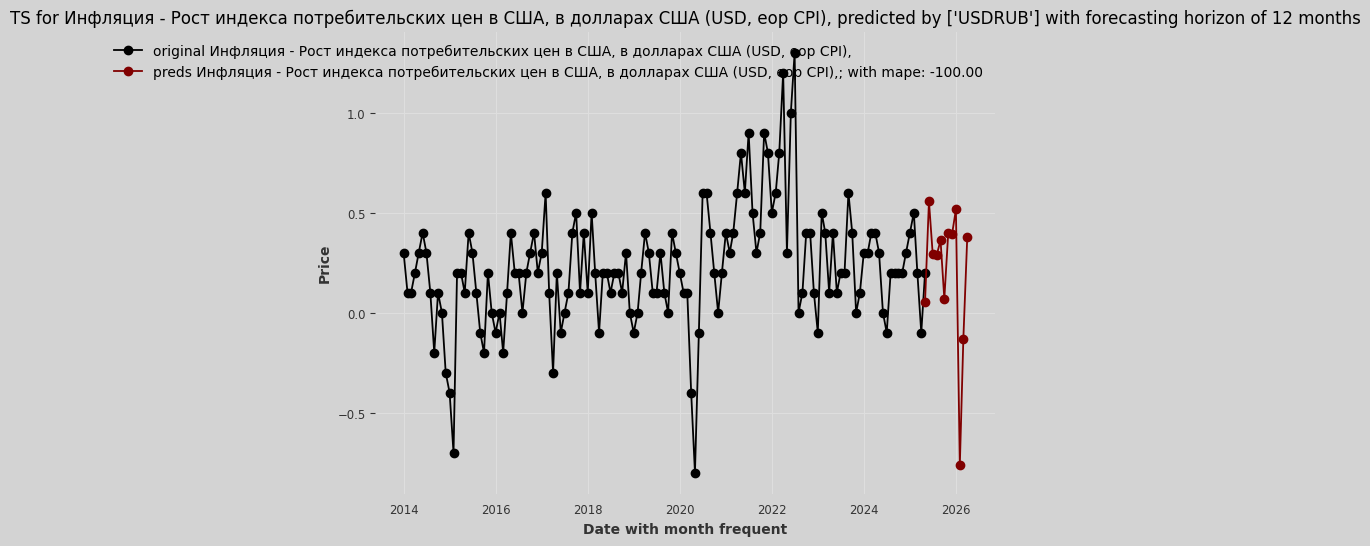

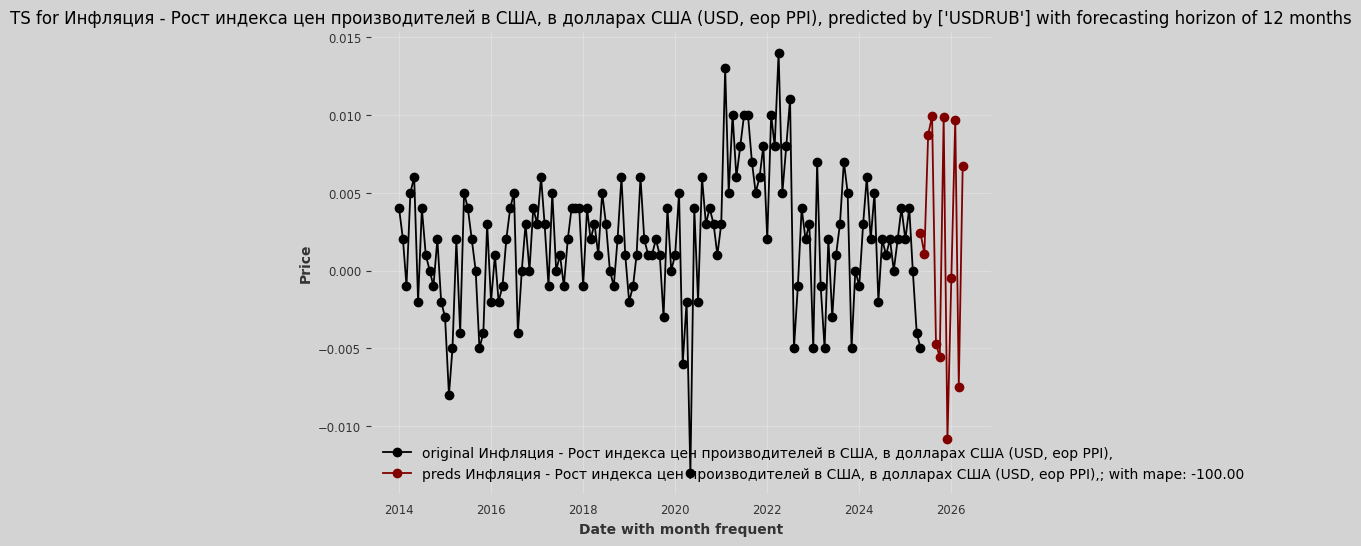

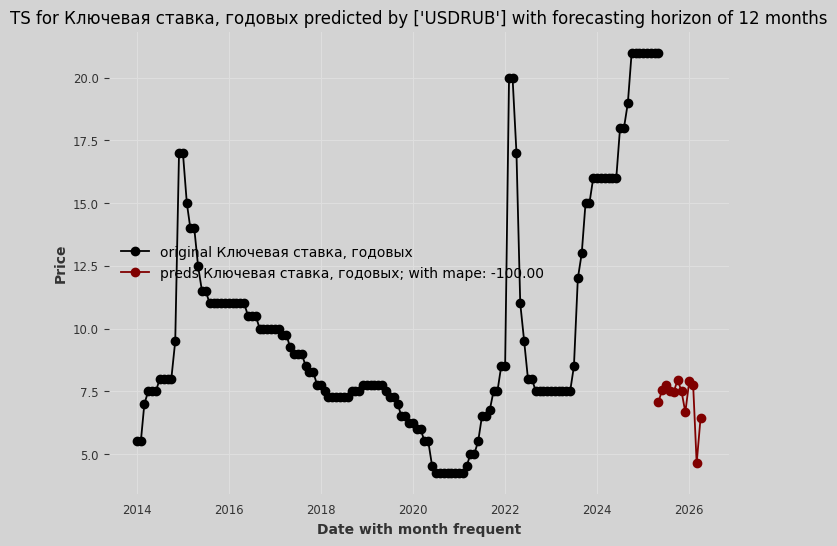

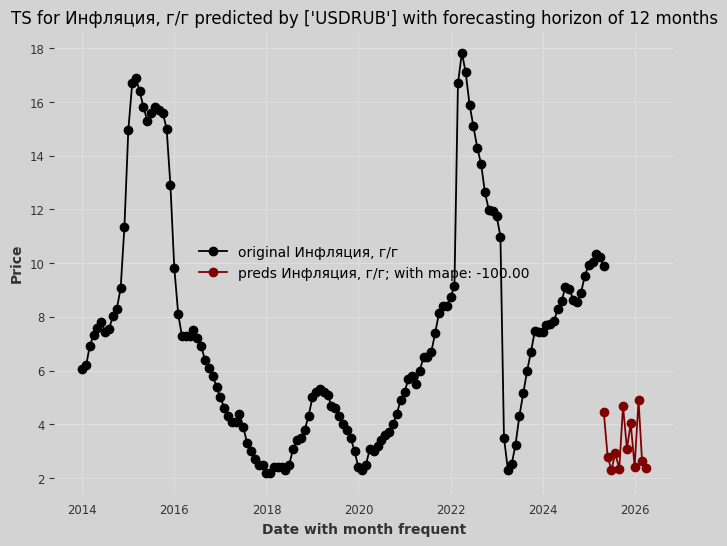

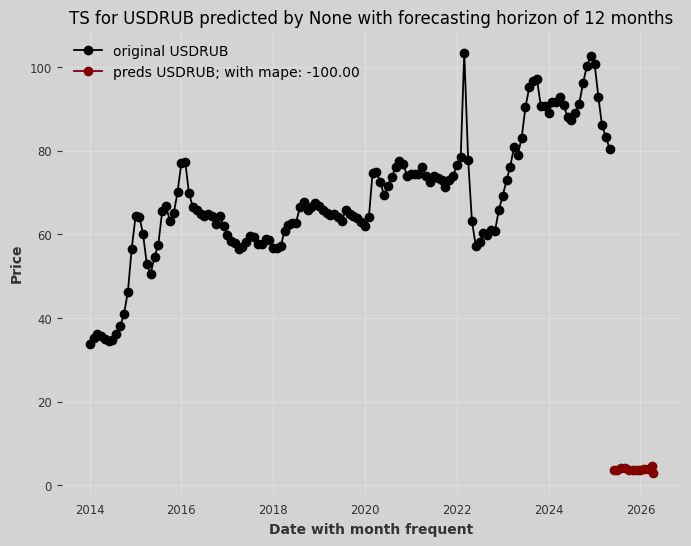

In [35]:
answer_last = pd.DataFrame([])
df_updated.columns = [col_name.replace("/", " ") for col_name in df_updated.columns]

for col in CATEGORY_MAP.keys():
    is_predicting_macro = col in macro_updated.columns
    df_for_col = macro_updated if is_predicting_macro else df_updated
    if col in ('Подсолнечное масло (наливом) не бутилированное, не'):
        continue
    category_to_pred = CATEGORY_MAP.get(col, "")
    if category_to_pred == "":
        continue
    cluster_preds, ts_prediction = get_prediction_for_ts(df_updated.dropna(),
                                          models[category_to_pred],
                                          col,
                                          use_future_macro = USE_FUTURE_COV,
                                          category_map = CATEGORY_MAP,
                                          best_predictors_for_idx = BEST_PREDICTORS_FOR_INDEX,
                                          future_forecaster_ts_name = FUTURE_FORECASTER_TS_NAME,
                                          future_forecaster_ts_values = FUTURE_FORECASTER_TS_VALUES,
                                          target_col_suffix = TARGET_COL_SUFFIX,
                                          prediction_horizon = PREDICTION_HORIZON)
    print(cluster_preds)
    answer_last = pd.concat([answer_last, ts_prediction], axis=1)
    plot_graphics_for_each_ts(df_for_col[f"{col}"],
                          ts_prediction[f"{col}_preds"],
                          None,
                          col,
                          -1,
                          -1,
                          BEST_PREDICTORS_FOR_INDEX[CATEGORY_MAP[col]],
                          "",
                          forecasting_horizon=PREDICTION_HORIZON)
answer_last.to_excel(f"prediction_up_to_2025_{MODEL_NAME_FOR_FORECASTER}_new_3.xlsx")